# Movie Recommendation System

## ALX Machine Learning Recommendation Challenge

### Table of Contents

1. [Project Introduction](#1-project-introduction)

2. [Dataset Loading and Exploration](#2-dataset-loading-and-exploration)

   * [2.1 Load the Training Data](#21-load-the-training-data)
   * [2.2 Inspect the Dataset Structure](#22-inspect-the-dataset-structure)
   * [2.3 Dataset Structure Summary](#23-dataset-structure-summary)

3. [Exploratory Data Analysis](#3-exploratory-data-analysis)

   * [3.1 Rating Distribution](#31-rating-distribution)
   * [3.2 Rating Distribution Visualization](#32-rating-distribution-visualization)
   * [3.3 Rating Distribution Summary](#33-rating-distribution-summary)
   * [3.4 Rating Distribution Analysis](#34-rating-distribution-analysis)
   * [3.5 Positive Rating Analysis](#35-positive-rating-analysis)
   * [3.6 Key Finding](#36-key-finding)
   * [3.7 User and Movie Rating Activity](#37-user-and-movie-rating-activity)
   * [3.8 Interpretation of User and Movie Rating Activity](#38-interpretation-of-user-and-movie-rating-activity)
   * [3.9 Overall Mean Rating](#39-overall-mean-rating)

4. [Baseline Model — Global Mean](#4-baseline-model--global-mean)

   * [4.1 Create a Validation Split](#41-create-a-validation-split)
   * [4.2 Generate Baseline Predictions](#42-generate-baseline-predictions)
   * [4.3 Baseline Result](#43-baseline-result)

5. [User + Movie Bias Model](#5-user--movie-bias-model)

   * [5.1 Calculating User and Movie Statistics](#51-calculating-user-and-movie-statistics)
   * [5.2 Regularization of User and Movie Biases](#52-regularization-of-user-and-movie-biases)
   * [5.3 Generating Predictions](#53-generating-predictions)
   * [5.4 Regularization Tuning](#54-regularization-tuning)
   * [5.5 Regularization Results](#55-regularization-results)
   * [5.6 Separate User and Movie Regularization](#56-separate-user-and-movie-regularization)

6. [Matrix Factorization — SVD](#6-matrix-factorization--svd)

   * [6.1 Preparing Data for SVD](#61-preparing-data-for-svd)
   * [6.2 Preparing the SVD Dataset](#62-preparing-the-svd-dataset)
   * [6.3 Training the SVD Model](#63-training-the-svd-model)
   * [6.4 Evaluating the SVD Model](#64-evaluating-the-svd-model)
   * [6.5 SVD Hyperparameter Tuning](#65-svd-hyperparameter-tuning)

     * [6.5.1 Testing Different Numbers of Latent Factors](#651-testing-different-numbers-of-latent-factors)
     * [6.5.2 Testing Different Numbers of Training Epochs](#652-testing-different-numbers-of-training-epochs)
   * [6.6 SVD Regularization Tuning](#66-svd-regularization-tuning)
   * [6.7 SVD Tuning Summary](#67-svd-tuning-summary)

7. [Model Comparison and Ensemble Modelling](#7-model-comparison-and-ensemble-modelling)

   * [7.1 Model Comparison](#71-model-comparison)
   * [7.2 Visual Comparison of Model Performance](#72-visual-comparison-of-model-performance)
   * [7.3 Model Ensemble](#73-model-ensemble)

     * [7.3.1 Generating Predictions from the Best Models](#731-generating-predictions-from-the-best-models)
     * [7.3.2 Training the Best SVD Model](#732-training-the-best-svd-model)
     * [7.3.3 Generating SVD Predictions](#733-generating-svd-predictions)
     * [7.3.4 Testing Ensemble Weights](#734-testing-ensemble-weights)
     * [7.3.5 Fine-Tuning the Ensemble Weight](#735-fine-tuning-the-ensemble-weight)
   * [7.4 Final Ensemble Configuration](#74-final-ensemble-configuration)

     * [7.4.1 Calculate Final Validation Predictions](#741-calculate-final-validation-predictions)
     * [7.4.2 Final Model Selection](#742-final-model-selection)

8. [Test Set Prediction & Submission](#8-test-set-prediction--submission)

   * [8.1 Loading the Test Dataset in Chunks](#81-loading-the-test-dataset-in-chunks)

     * [8.1.1 Inspecting the Test Data](#811-inspecting-the-test-data)
   * [8.2 Memory-Safe Test Prediction](#82-memory-safe-test-prediction)

     * [8.2.1 Testing Prediction on a Single Chunk](#821-testing-prediction-on-a-single-chunk)
     * [8.2.2 Generating SVD Predictions for the Test Chunk](#822-generating-svd-predictions-for-the-test-chunk)
     * [8.2.3 Generating Final Ensemble Predictions](#823-generating-final-ensemble-predictions)
     * [8.2.4 Clipping Predictions to the Valid Rating Range](#824-clipping-predictions-to-the-valid-rating-range)
   * [8.3 Full Test Prediction](#83-full-test-prediction)

     * [8.3.1 Preparing the Final Submission File](#831-preparing-the-final-submission-file)
     * [8.3.2 Full Test Prediction and Submission](#832-full-test-prediction-and-submission)
   * [8.4 Submission Validation](#84-submission-validation)

     * [8.4.1 Checking the Submission File](#841-checking-the-submission-file)
     * [8.4.2 Final Submission Summary](#842-final-submission-summary)
     * [8.4.3 Inspecting the Kaggle Submission Template](#843-inspecting-the-kaggle-submission-template)
     * [8.4.4 Correcting the Submission Format](#844-correcting-the-submission-format)
     * [8.4.5 Final Submission Format Validation](#845-final-submission-format-validation)
   * [8.5 Kaggle Submission Result](#85-kaggle-submission-result)

9. [Final Model & Results](#9-final-model--results)

   * [9.1 Interpretation of Final Model Results](#91-interpretation-of-final-model-results)
   * [9.2 Final Model Comparison](#92-final-model-comparison)

10. [Project Conclusions](#10-project-conclusions)

* [10.1 Key Lessons Learned](#101-key-lessons-learned)
* [10.2 Limitations & Future Improvements](#102-limitations--future-improvements)

11. [Final Project Summary](#11-final-project-summary)


# 1. Project Introduction

## Project Overview

This project focuses on building and evaluating a **Movie Recommendation System** using a large-scale version of the **MovieLens dataset** provided through a Kaggle recommendation-system competition.

The project was completed as part of the ALX Data Science learning programme and uses the Kaggle competition environment to apply recommendation-system techniques to a real-world prediction problem.

Recommender systems are widely used by platforms such as Netflix, Amazon Prime, Disney+, and other content platforms to help users discover content that matches their interests. In this competition, the objective is to develop a recommendation algorithm capable of predicting how a user would rate a movie that they have not yet rated, based on patterns learned from historical user-movie ratings.

## Competition Objective

The competition provides historical ratings for users and movies in a training dataset. The task is to learn the relationship between users and movies and then predict ratings for user-movie pairs in an unseen test dataset.

Conceptually, the prediction problem can be represented as:

$$
\text{User} + \text{Movie} \rightarrow \text{Predicted Rating}
$$

The predicted ratings are submitted to Kaggle, where they are evaluated against the hidden actual ratings.

The competition uses **Root Mean Squared Error (RMSE)** as its evaluation metric, with lower values indicating better predictive performance.

## Dataset Overview

The dataset is based on **MovieLens**, a widely used dataset for recommender-system research maintained by the **GroupLens Research Group** at the University of Minnesota.

The competition uses a specially prepared version of MovieLens that has been **resampled for evaluation purposes and enriched with additional movie-related information**, including metadata from IMDb.

The main training dataset contains more than **10 million ratings**, while the test dataset contains approximately **5 million user-movie pairs** for which the ratings must be predicted.

The primary files used in the recommendation task include:

* `train.csv` — contains historical user-movie ratings.
* `test.csv` — contains user-movie pairs for which ratings must be predicted.
* `sample_submission.csv` — provides the required Kaggle submission format.

Additional files supplied by the competition include movie metadata, tags, genome scores, genome tags, and links to external movie databases.

## Training Data Structure

The main training file, `train.csv`, contains four columns:

| Column      | Description                           |
| ----------- | ------------------------------------- |
| `userId`    | Unique identifier for the user        |
| `movieId`   | Unique identifier for the movie       |
| `rating`    | Rating given by the user              |
| `timestamp` | Time at which the rating was recorded |

Ratings are provided on a **5-star scale in half-star increments**, ranging from **0.5 to 5.0**.

The test file contains `userId` and `movieId`, but does not contain the rating. These missing ratings are what the recommendation models are required to predict.

Therefore:

$$
\text{Training Data: User + Movie} \rightarrow \text{Known Rating}
$$

$$
\text{Test Data: User + Movie} \rightarrow \text{Unknown Rating}
$$

## Additional Movie Information

The competition also provides additional information that can potentially be used to improve recommendation performance.

This includes:

* Movie genres and titles
* User-generated movie tags
* Tag genome relevance scores
* IMDb-related movie metadata
* Movie identifier mappings to IMDb and TMDB

Some of these additional sources were explored during the project. However, not all were incorporated into the final model because of computational and memory constraints.

For example, an exploratory genome-tag experiment generated a very large number of user-tag combinations and became computationally impractical on the available **8 GB RAM** system. This experiment was therefore documented as an exploratory attempt rather than being included in the final model.

## Evaluation Metric

The primary evaluation metric for this project is **Root Mean Squared Error (RMSE)**.

RMSE measures the difference between predicted ratings and the actual ratings:

$$
RMSE =
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\hat{y}_i)^2
}
$$

where:

* $n$ = number of observations
* $y_i$ = actual rating
* $\hat{y}_i$ = predicted rating

A lower RMSE indicates better predictive performance because the predicted ratings are closer to the actual ratings.

RMSE gives greater importance to larger errors because the differences between predicted and actual ratings are squared before averaging.

## Modelling Approach

The project follows a progressive modelling approach, beginning with a simple baseline and gradually introducing more sophisticated recommendation techniques.

The main approaches evaluated were:

1. **Global Mean Baseline**
2. **User + Movie Bias Model**
3. **SVD / Matrix Factorization**
4. **Hyperparameter Tuning**
5. **Weighted Ensemble of User + Movie Bias and SVD**

The models were compared using the same validation framework and RMSE metric to determine whether increased model complexity produced meaningful improvements.

## Computational Constraints

The MovieLens dataset contains more than **10 million ratings**, while the available system has approximately **8 GB of RAM**.

As a result, computational efficiency and memory management were important considerations throughout the project.

Memory-aware techniques were used where necessary, including data sampling during some experiments and **chunk-based processing of the approximately 5-million-row test dataset** during final prediction generation.

These constraints also influenced the range of experiments that could be performed.

## Project Goal

The goal of this project is to develop the **best practical movie recommendation model possible under the available computational resources**, while understanding how different recommendation techniques perform and why.

The project therefore focuses not only on achieving a low RMSE, but also on demonstrating a complete machine learning workflow involving **data exploration, baseline modelling, collaborative filtering, matrix factorization, hyperparameter tuning, ensemble modelling, memory-efficient prediction, and Kaggle submission**.


## Project Setup

Before loading the dataset, the required Python libraries are imported and the available system memory is checked.

Because the MovieLens dataset contains more than 10 million ratings, monitoring memory usage is important throughout the project. The available hardware has **8 GB of RAM**, so memory-efficient processing techniques are used where necessary.


In [1]:
import numpy as np
import pandas as pd
import os
import gc
import psutil

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


ram = psutil.virtual_memory()

print(f"Total RAM: {ram.total / (1024**3):.2f} GB")
print(f"Available RAM: {ram.available / (1024**3):.2f} GB")
print(f"Used RAM: {ram.used / (1024**3):.2f} GB")
print(f"Percent Used: {ram.percent:.1f}%")

Total RAM: 7.88 GB
Available RAM: 1.41 GB
Used RAM: 6.47 GB
Percent Used: 82.1%


# 2. Dataset Loading and Exploration

The MovieLens dataset contains user ratings and additional movie-related information.

For the core recommendation task, we primarily need:

* `train.csv` — historical user ratings used to train and validate the model.
* `test.csv` — user-movie pairs for which ratings must be predicted.
* `sample_submission.csv` — required format for the final Kaggle submission.

The training dataset contains **10,000,038 ratings**, so memory usage must be considered throughout the project.


In [2]:
import os

data_path = r"C:\Users\TITILOPE\OneDrive\Downloads\ALX DATA SCIENCE LEARNINGS\3_MACHINE LEARNING\3_UNSUPERVISED LEARNING MODULES\movie-recommendation-hackathon-2026"

train_path = os.path.join(data_path, "train.csv")
test_path = os.path.join(data_path, "test.csv")
submission_path = os.path.join(data_path, "sample_submission.csv")

print("Train exists:", os.path.exists(train_path))
print("Test exists:", os.path.exists(test_path))
print("Sample submission exists:", os.path.exists(submission_path))

Train exists: True
Test exists: True
Sample submission exists: True


## 2.1 Load the Training Data

The training dataset contains historical ratings given by users to movies.

Each row represents one rating event and contains:

* `userId` — unique identifier for the user.
* `movieId` — unique identifier for the movie.
* `rating` — rating given by the user.
* `timestamp` — time at which the rating was recorded.

The dataset contains **10,000,038 observations**, so memory usage will be monitored while working with it.


In [3]:
train = pd.read_csv(
    train_path,
    usecols=["userId", "movieId", "rating", "timestamp"]
)

print("Training shape:", train.shape)
print("\nFirst 5 rows:")
display(train.head())

Training shape: (10000038, 4)

First 5 rows:


,userId,movieId,rating,timestamp
0,5163,57669,4.0,1518349992
1,106343,5,4.5,1206238739
2,146790,5459,5.0,1076215539
3,106362,32296,2.0,1423042565
4,9041,366,3.0,833375837


## 2.2 Inspect the Dataset Structure

The basic structure of the training dataset is inspected to understand its columns, data types, memory usage, number of unique users and movies, and the presence of missing values.

In [4]:
print(train.info())

<class 'pandas.DataFrame'>
RangeIndex: 10000038 entries, 0 to 10000037
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 305.2 MB
None


In [5]:
print("\nUnique users:", train["userId"].nunique())
print("Unique movies:", train["movieId"].nunique())
print("Missing values:")
print(train.isnull().sum())


Unique users: 162541
Unique movies: 48213
Missing values:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


## 2.3 Dataset Structure Summary

The training dataset contains **10,000,038 rating records** and **4 columns**:

* **`userId`** (`int64`) — identifies the user who provided the rating.
* **`movieId`** (`int64`) — identifies the movie being rated.
* **`rating`** (`float64`) — the rating assigned by the user.
* **`timestamp`** (`int64`) — records when the rating was given.

The dataset contains **162,541 unique users** and **48,213 unique movies**.

There are **no missing values** in any of the four columns, so no missing-value treatment is required for the core rating data at this stage.

The dataset occupies approximately **305 MB in memory** when loaded as a pandas DataFrame. Because the computer has only 8 GB of RAM, memory usage will remain an important consideration throughout the modelling process.


# 3. Exploratory Data Analysis

We begin the exploratory data analysis by examining the distribution of ratings, because understanding how users rate movies is important before building a prediction model.

## 3.1 Rating Distribution

Before building recommendation models, we examine the distribution of ratings in the training data.

This helps us understand:

* The range of ratings given by users.
* The average rating.
* How frequently different rating values occur.
* Whether the ratings are balanced or concentrated around particular values.

Understanding the rating distribution is also important because a model that simply predicts the average rating can already provide a useful baseline.


In [6]:
print("Rating statistics:")
print(train["rating"].describe())

Rating statistics:
count    1.000004e+07
mean     3.533395e+00
std      1.061124e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64


In [7]:
rating_counts = train["rating"].value_counts().sort_index()

print(rating_counts)

rating
0.5     157571
1.0     311213
1.5     159731
2.0     656821
2.5     505578
3.0    1959759
3.5    1270642
4.0    2652977
4.5     880516
5.0    1445230
Name: count, dtype: int64


## 3.2 Rating Distribution Visualization

The following chart shows how frequently each rating value occurs in the training dataset.

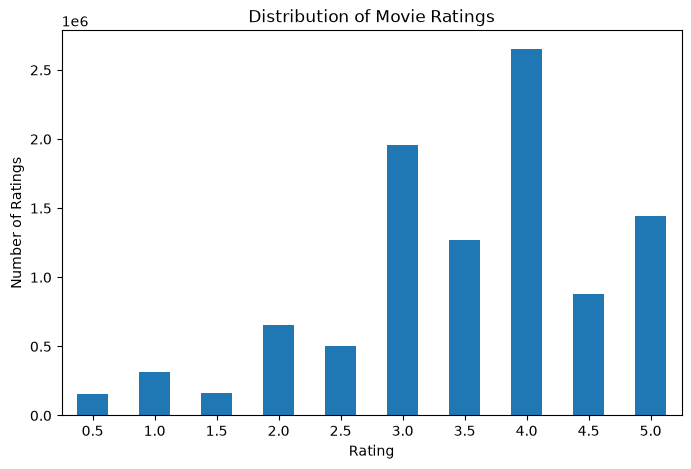

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
train["rating"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=0)
plt.show()

## 3.3 Rating Distribution Summary

The rating distribution is **uneven**, with some rating values occurring much more frequently than others.

This indicates that users do not rate movies uniformly across the available rating scale. Certain ratings are substantially more common, meaning the dataset has a noticeable concentration around particular values.

The `describe()` statistics provide the overall numerical summary of the ratings, including the mean, standard deviation, minimum, maximum, and quartiles.

This uneven distribution is important for the recommendation task because a model that simply predicts the overall average rating can already achieve a reasonable level of accuracy. Therefore, the **Global Mean** will be used as our first baseline model before introducing more sophisticated approaches.


In [9]:
rating_counts = train["rating"].value_counts().sort_index()

rating_percent = (
    train["rating"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

rating_distribution = pd.DataFrame({
    "Count": rating_counts,
    "Percentage": rating_percent.round(2)
})

display(rating_distribution)

,Count,Percentage
rating,,
0.5,157571,1.58
1.0,311213,3.11
1.5,159731,1.60
2.0,656821,6.57
2.5,505578,5.06
3.0,1959759,19.60
3.5,1270642,12.71
4.0,2652977,26.53
4.5,880516,8.81


## 3.4 Rating Distribution Analysis

The rating distribution is clearly **uneven** across the available rating scale.

The most common rating is **4.0**, accounting for approximately **26.53%** of all ratings. This is followed by **3.0 (19.60%)**, **5.0 (14.45%)**, and **3.5 (12.71%)**.

Lower ratings such as **0.5 (1.58%)**, **1.0 (3.11%)**, and **1.5 (1.60%)** occur considerably less frequently.

Overall, the distribution shows that users tend to give relatively positive ratings, with ratings of **3.0 and above accounting for the majority of observations**.

This imbalance means that establishing a **Global Mean baseline** is an important first step before developing more sophisticated recommendation models.


## 3.5 Positive Rating Analysis

To quantify the concentration of relatively positive ratings, we calculate the proportion of ratings that are **3.0 or higher**.

In [10]:
positive_ratings = train.loc[train["rating"] >= 3.0, "rating"]

print(
    f"Ratings >= 3.0: "
    f"{len(positive_ratings):,} "
    f"({len(positive_ratings) / len(train) * 100:.2f}%)"
)

Ratings >= 3.0: 8,209,124 (82.09%)


## 3.6 Key Finding

A total of **8,209,124 ratings (82.09%)** are 3.0 or higher.

This confirms that the dataset is strongly concentrated toward relatively positive ratings. Only about **17.91%** of ratings are below 3.0.

This positive skew is important when interpreting model performance. A prediction model should not only learn individual user and movie preferences but should also account for the overall tendency of users in the dataset to give relatively high ratings.


## 3.7 User and Movie Rating Activity

The number of ratings associated with each user and movie provides insight into the structure of the recommendation problem.

Users with many ratings provide more information about their preferences, while users with very few ratings provide less information.

Similarly, movies with many ratings have more evidence from which their general popularity can be estimated, while movies with very few ratings have greater uncertainty.

This analysis is particularly relevant for the **User + Movie Bias** models developed later, because the amount of rating history available for each user and movie influences how reliably their individual biases can be estimated.


In [11]:
user_rating_counts = train["userId"].value_counts()
movie_rating_counts = train["movieId"].value_counts()

print("User rating count statistics:")
print(user_rating_counts.describe())

print("\nMovie rating count statistics:")
print(movie_rating_counts.describe())

User rating count statistics:
count    162541.000000
mean         61.523173
std         107.410889
min           1.000000
25%          14.000000
50%          28.000000
75%          65.000000
max       12952.000000
Name: count, dtype: float64

Movie rating count statistics:
count    48213.000000
mean       207.413727
std       1092.768777
min          1.000000
25%          1.000000
50%          4.000000
75%         26.000000
max      32831.000000
Name: count, dtype: float64


## 3.8 Interpretation of User and Movie Rating Activity

The number of ratings per user varies considerably. There are **162,541 users**, with an average of approximately **61.5 ratings per user**. However, the median is only **28 ratings**, while the most active user has **12,952 ratings**.

This difference between the mean and median indicates that a relatively small number of highly active users contribute a large number of ratings.

Movie activity is even more uneven. Across **48,213 movies**, the average movie has approximately **207 ratings**, but the median is only **4 ratings**. At least 25% of the movies have only **one rating**, while the most-rated movie has **32,831 ratings**.

The large difference between the mean and median, particularly for movies, indicates a strong **long-tail distribution**. A small number of popular movies receive many ratings, while a large number of movies receive relatively few ratings.

This observation is important for model development because estimating a user's or movie's bias is more reliable when sufficient rating history is available. **Regularization** will therefore be important when estimating user and movie biases, particularly for users or movies with limited rating history.


## 3.9 Overall Mean Rating

The **Global Mean** is the average rating across all observations in the training dataset.

It provides the simplest possible prediction strategy: predict the same average rating for every user-movie pair.

Although this approach ignores individual user preferences and movie characteristics, it provides an important baseline against which more advanced models can be compared.

The Global Mean will therefore serve as the starting point for evaluating whether the more sophisticated recommendation models provide meaningful improvements.


In [12]:
global_mean = train["rating"].mean()

print(f"Global mean rating: {global_mean:.4f}")

Global mean rating: 3.5334


# 4. Baseline Model — Global Mean

The Global Mean model is our simplest recommendation baseline.

It predicts the same rating for every user-movie pair. The prediction is calculated as:

$$
\hat{r}_{u,i} = \mu
$$

where:

* $\hat{r}_{u,i}$ = predicted rating for user $u$ and movie $i$.
* $\mu$ = global mean rating calculated from the training dataset.

The global mean is calculated using:

$$
\mu = \frac{1}{N}\sum_{j=1}^{N} r_j
$$

where:

* $N$ = total number of ratings in the training dataset.
* $r_j$ = the actual rating for observation $j$.

For this dataset, the global mean rating is approximately **3.5334** before the train-validation split.

The purpose of this baseline is not to produce the best recommendations. Instead, it provides a reference point that allows us to determine whether more sophisticated models are actually learning useful patterns from the data.

A good recommendation model should achieve a lower RMSE than this baseline.


## 4.1 Create a Validation Split

To evaluate the baseline fairly, the dataset is divided into a **training set** and a **validation set**.

The model must not use the validation ratings when calculating the global mean. Otherwise, information from the validation set would leak into the model and produce an overly optimistic evaluation.

An **80/20 split** is used, with 80% of the ratings assigned to training and 20% reserved for validation.

```python
train_data, validation_data = train_test_split(
    train,
    test_size=0.20,
    random_state=42
)

print("Training set:", train_data.shape)
print("Validation set:", validation_data.shape)
```

The resulting datasets are:

* **Training set:** 8,000,030 ratings
* **Validation set:** 2,000,008 ratings

The Global Mean is then calculated using **only the training data**:

```python
baseline_mean = train_data["rating"].mean()

print(f"Training mean rating: {baseline_mean:.4f}")
```

The calculated training mean is:

**3.5335**

This value will be used as the prediction for every user-movie pair in the validation set.


In [13]:
train_data, validation_data = train_test_split(
    train,
    test_size=0.20,
    random_state=42
)

print("Training set:", train_data.shape)
print("Validation set:", validation_data.shape)

Training set: (8000030, 4)
Validation set: (2000008, 4)


Then calculate the mean from the training portion only:

In [14]:
baseline_mean = train_data["rating"].mean()

print(f"Training mean rating: {baseline_mean:.4f}")

Training mean rating: 3.5335


## 4.2 Generate Baseline Predictions

The Global Mean baseline predicts the training mean rating for every user-movie pair in the validation set.

```python
baseline_predictions = np.full(
    len(validation_data),
    baseline_mean
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        validation_data["rating"],
        baseline_predictions
    )
)

print(f"Global Mean Baseline RMSE: {baseline_rmse:.6f}")
```

The resulting validation RMSE is:

**1.060875**


In [15]:
baseline_predictions = np.full(
    len(validation_data),
    baseline_mean
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        validation_data["rating"],
        baseline_predictions
    )
)

print(f"Global Mean Baseline RMSE: {baseline_rmse:.6f}")

Global Mean Baseline RMSE: 1.060875


## 4.3 Baseline Result

The Global Mean model achieved an RMSE of **1.060875** on the validation set.

This means that predicting the same rating, approximately **3.5335**, for every user-movie pair provides a relatively weak but useful baseline.

The model does not consider:

* Individual user preferences
* Differences in movie popularity
* Differences in how users tend to rate movies

Therefore, we expect a model that captures **user-specific and movie-specific rating tendencies** to perform substantially better.

This baseline will serve as the reference point for evaluating all subsequent recommendation models. A lower RMSE will indicate an improvement over the Global Mean approach.


# 5. User + Movie Bias Model

The Global Mean model assumes that every user and every movie behaves the same way. This is unrealistic for a recommendation system.

For example:

* Some users tend to give higher ratings than average.
* Some users tend to give lower ratings than average.
* Some movies are generally rated more positively.
* Some movies are generally rated more negatively.

To capture these systematic differences, we introduce **user and movie biases**.

The prediction is defined as:

$$
\hat{r}_{u,i} = \mu + b_u + b_i
$$

where:

* $\hat{r}_{u,i}$ = predicted rating for user $u$ and movie $i$.
* $\mu$ = global mean rating.
* $b_u$ = user bias.
* $b_i$ = movie bias.

A positive user bias means that the user generally rates movies above the global average, while a negative bias means the user tends to rate below the average.

Similarly, a positive movie bias indicates that a movie tends to receive ratings above the global average, while a negative movie bias indicates that the movie tends to receive ratings below the average.

Because some users and movies have very few ratings, their bias estimates can be unreliable. We therefore use **regularization** to prevent users or movies with limited rating history from receiving excessively large bias values.

This model extends the Global Mean baseline by allowing the prediction to account for systematic differences between users and movies.


## 5.1 Calculating User and Movie Statistics

To estimate user and movie biases, we first calculate two statistics for each user and movie:

* **Sum of ratings** — the total rating points associated with the user or movie.
* **Count of ratings** — the number of ratings associated with the user or movie.

These statistics allow us to determine whether a user or movie tends to receive ratings above or below the global mean.

The calculations are performed using grouped statistics rather than creating large additional datasets. This approach helps reduce unnecessary memory usage given the size of the MovieLens dataset.


In [16]:
global_mean_train = train_data["rating"].mean()

user_stats = train_data.groupby("userId")["rating"].agg(["sum", "count"])
movie_stats = train_data.groupby("movieId")["rating"].agg(["sum", "count"])

print("Users:", len(user_stats))
print("Movies:", len(movie_stats))

Users: 162538
Movies: 45438


### Interpretation

The training portion contains rating history for **162,538 users** and **45,438 movies**.

These grouped statistics provide the information needed to estimate how individual users and movies differ from the overall rating average.

The number of users and movies is slightly lower than in the complete dataset because the model is being trained on only **80% of the original ratings**. Some users or movies may therefore have no ratings in the training portion and will be handled appropriately when generating validation predictions.


## 5.2 Regularization of User and Movie Biases

A direct calculation of user and movie biases can produce unreliable estimates when a user or movie has only a small number of ratings.

For example, a movie with only one rating of 5.0 should not automatically be considered a movie that users generally rate extremely highly.

To reduce the influence of such limited observations, we introduce **regularization**.

The regularized user bias is estimated as:

$$
b_u =
\frac{\sum_{i \in I_u}(r_{u,i} - \mu)}
{|I_u| + \lambda_u}
$$

The regularized movie bias is estimated as:

$$
b_i =
\frac{\sum_{u \in U_i}(r_{u,i} - \mu)}
{|U_i| + \lambda_i}
$$

where:

* $b_u$ = user bias.
* $b_i$ = movie bias.
* $r_{u,i}$ = observed rating given by user $u$ to movie $i$.
* $\mu$ = global mean rating.
* $|I_u|$ = number of ratings given by user $u$.
* $|U_i|$ = number of ratings received by movie $i$.
* $\lambda_u$ = user regularization parameter.
* $\lambda_i$ = movie regularization parameter.

A larger regularization value reduces the magnitude of the estimated bias, particularly when there are relatively few observations.

For the initial model, we will use a regularization value of **10** for both users and movies.


In [17]:
user_reg = 10
movie_reg = 10

user_bias = (
    (user_stats["sum"] - user_stats["count"] * global_mean_train)
    / (user_stats["count"] + user_reg)
)

movie_bias = (
    (movie_stats["sum"] - movie_stats["count"] * global_mean_train)
    / (movie_stats["count"] + movie_reg)
)

print("User biases:", len(user_bias))
print("Movie biases:", len(movie_bias))

User biases: 162538
Movie biases: 45438


### Interpretation

The model successfully estimated a bias value for each of the **162,538 users** and **45,438 movies** represented in the training data.

The regularization parameter of **10** helps prevent users or movies with relatively few ratings from receiving excessively large bias values.

These learned biases will now be combined with the global mean rating to generate personalized predictions for the validation dataset.


## 5.3 Generating Predictions

The final prediction combines the global mean with the estimated user and movie biases:

$$
\hat{r}_{u,i} = \mu + b_u + b_i
$$

For each user-movie pair in the validation set, we look up the corresponding user and movie biases.

If a user or movie is not present in the training data, its bias cannot be estimated. In such cases, we assign a bias of **zero**, effectively falling back toward the global mean.

The predictions are then evaluated using **RMSE**.


In [18]:
validation_users = validation_data["userId"].map(user_bias).fillna(0)
validation_movies = validation_data["movieId"].map(movie_bias).fillna(0)

bias_predictions = (
    global_mean_train
    + validation_users.values
    + validation_movies.values
)

bias_rmse = np.sqrt(
    mean_squared_error(
        validation_data["rating"],
        bias_predictions
    )
)

print(f"User + Movie Bias RMSE: {bias_rmse:.6f}")

User + Movie Bias RMSE: 0.880608


### Interpretation

The User + Movie Bias model achieved an RMSE of **0.880608**, compared with **1.060875** for the Global Mean baseline.

This represents a substantial improvement in prediction accuracy.

The improvement occurs because the model captures two important sources of variation in ratings:

* **User-specific behavior** — some users consistently rate movies higher or lower than average.
* **Movie-specific behavior** — some movies consistently receive higher or lower ratings than average.

The result demonstrates that incorporating user and movie effects provides significantly more useful information than predicting the same global mean rating for every user-movie pair.

However, the regularization value was chosen as an initial setting. We will therefore investigate whether different regularization strengths can further improve the model's RMSE.


## 5.4 Regularization Tuning

The regularization parameters control how strongly user and movie biases are constrained.

A very small regularization value may allow users or movies with limited rating history to have excessively large biases.

A very large regularization value may constrain the biases too strongly and prevent the model from capturing meaningful differences.

We will therefore evaluate several regularization values and compare their validation RMSE.

The values tested are:

$$
\lambda \in {1, 5, 10, 20}
$$

The same regularization value will initially be applied to both users and movies.


In [19]:
regularization_values = [1, 5, 10, 20]

results = []

for reg in regularization_values:

    user_bias_temp = (
        (user_stats["sum"] - user_stats["count"] * global_mean_train)
        / (user_stats["count"] + reg)
    )

    movie_bias_temp = (
        (movie_stats["sum"] - movie_stats["count"] * global_mean_train)
        / (movie_stats["count"] + reg)
    )

    pred = (
        global_mean_train
        + validation_data["userId"].map(user_bias_temp).fillna(0).values
        + validation_data["movieId"].map(movie_bias_temp).fillna(0).values
    )

    rmse = np.sqrt(
        mean_squared_error(
            validation_data["rating"],
            pred
        )
    )

    results.append((reg, rmse))

    print(f"Regularization {reg}: RMSE = {rmse:.6f}")

Regularization 1: RMSE = 0.887056
Regularization 5: RMSE = 0.882082
Regularization 10: RMSE = 0.880608
Regularization 20: RMSE = 0.881221


### Interpretation

The results show that the choice of regularization has a noticeable effect on model performance.

| Regularization |         RMSE |
| -------------: | -----------: |
|              1 |     0.887056 |
|              5 |     0.882082 |
|         **10** | **0.880608** |
|             20 |     0.881221 |

The best result was obtained with a regularization value of **10**, achieving an RMSE of **0.880608**.

A very small regularization value of 1 produced a higher RMSE because the model was less constrained. Increasing the regularization to 5 and then 10 improved performance.

However, increasing the value further to 20 slightly worsened the RMSE. This suggests that stronger regularization begins to restrict the model from capturing useful user and movie differences.

Therefore, **10 is selected as the best regularization value among the values tested** for the current User + Movie Bias model.


## 5.5 Regularization Results

The tuning results are stored in a DataFrame so that they can be easily compared and visualized later alongside the results of other recommendation models.


In [20]:
regularization_results = pd.DataFrame(
    results,
    columns=["Regularization", "RMSE"]
)

display(regularization_results)

,Regularization,RMSE
0,1,0.887056
1,5,0.882082
2,10,0.880608
3,20,0.881221


In [21]:
best_row = regularization_results.loc[
    regularization_results["RMSE"].idxmin()
]

print(f"Best regularization: {best_row['Regularization']}")
print(f"Best RMSE: {best_row['RMSE']:.6f}")

Best regularization: 10.0
Best RMSE: 0.880608


## 5.6 Separate User and Movie Regularization

The previous experiment applied the same regularization value to both users and movies.

However, the EDA showed that user and movie rating activity has very different distributions. Users have substantially more ratings on average, while many movies have very few ratings.

Because the amount of available information differs between users and movies, using separate regularization parameters may improve the model.

The prediction remains:

$$
\hat{r}_{u,i} = \mu + b_u + b_i
$$

but the bias estimates use separate regularization parameters:

$$
b_u =
\frac{
\sum_{i \in I_u}(r_{u,i}-\mu)
}{
n_u+\lambda_u
}
$$

$$
b_i =
\frac{
\sum_{u \in U_i}(r_{u,i}-\mu)
}{
n_i+\lambda_i
}
$$

where:

* $\lambda_u$ = user regularization parameter.
* $\lambda_i$ = movie regularization parameter.
* $n_u$ = number of ratings given by user $u$.
* $n_i$ = number of ratings received by movie $i$.

We will test several combinations of user and movie regularization values to determine whether different regularization strengths provide better validation performance.


In [22]:
user_regs = [5, 10, 20]
movie_regs = [5, 10, 20]

grid_results = []

for user_reg in user_regs:
    for movie_reg in movie_regs:

        user_bias_temp = (
            (user_stats["sum"] - user_stats["count"] * global_mean_train)
            / (user_stats["count"] + user_reg)
        )

        movie_bias_temp = (
            (movie_stats["sum"] - movie_stats["count"] * global_mean_train)
            / (movie_stats["count"] + movie_reg)
        )

        pred = (
            global_mean_train
            + validation_data["userId"].map(user_bias_temp).fillna(0).values
            + validation_data["movieId"].map(movie_bias_temp).fillna(0).values
        )

        rmse = np.sqrt(
            mean_squared_error(
                validation_data["rating"],
                pred
            )
        )

        grid_results.append(
            (user_reg, movie_reg, rmse)
        )

        print(
            f"User reg {user_reg}, "
            f"Movie reg {movie_reg}: "
            f"RMSE = {rmse:.6f}"
        )

User reg 5, Movie reg 5: RMSE = 0.882082
User reg 5, Movie reg 10: RMSE = 0.881748
User reg 5, Movie reg 20: RMSE = 0.881543
User reg 10, Movie reg 5: RMSE = 0.880933
User reg 10, Movie reg 10: RMSE = 0.880608
User reg 10, Movie reg 20: RMSE = 0.880417
User reg 20, Movie reg 5: RMSE = 0.881693
User reg 20, Movie reg 10: RMSE = 0.881385
User reg 20, Movie reg 20: RMSE = 0.881221


### Interpretation

The grid search tested nine combinations of user and movie regularization values.

| User Reg | Movie Reg |         RMSE |
| -------: | --------: | -----------: |
|        5 |         5 |     0.882082 |
|        5 |        10 |     0.881748 |
|        5 |        20 |     0.881543 |
|       10 |         5 |     0.880933 |
|       10 |        10 |     0.880608 |
|   **10** |    **20** | **0.880417** |
|       20 |         5 |     0.881693 |
|       20 |        10 |     0.881385 |
|       20 |        20 |     0.881221 |

The best combination was **user regularization = 10** and **movie regularization = 20**, producing an RMSE of **0.880417**.

The stronger regularization applied to movies is consistent with the earlier EDA findings. Movies have a much lower median rating count than users, meaning that many movie bias estimates are based on relatively little information. Stronger regularization helps prevent these estimates from becoming excessively influenced by a small number of ratings.

Compared with the previous model using regularization of 10 for both users and movies, the RMSE improved from **0.880608 to 0.880417**.

Therefore, the selected User + Movie Bias configuration for this experiment is:

* **User regularization: 10**
* **Movie regularization: 20**
* **Validation RMSE: 0.880417**

The results are then stored in a DataFrame to maintain a clean record for later comparison with the other recommendation models.


In [23]:
grid_results_df = pd.DataFrame(
    grid_results,
    columns=["User_Reg", "Movie_Reg", "RMSE"]
)

display(grid_results_df)

,User_Reg,Movie_Reg,RMSE
0,5,5,0.882082
1,5,10,0.881748
2,5,20,0.881543
3,10,5,0.880933
4,10,10,0.880608
5,10,20,0.880417
6,20,5,0.881693
7,20,10,0.881385
8,20,20,0.881221


Then identify the best combination:

In [24]:
best_grid_row = grid_results_df.loc[
    grid_results_df["RMSE"].idxmin()
]

print(f"Best user regularization: {int(best_grid_row['User_Reg'])}")
print(f"Best movie regularization: {int(best_grid_row['Movie_Reg'])}")
print(f"Best Bias Model RMSE: {best_grid_row['RMSE']:.6f}")

Best user regularization: 10
Best movie regularization: 20
Best Bias Model RMSE: 0.880417


# 6. Matrix Factorization — SVD

The User + Movie Bias model captures systematic differences between users and movies, but it does not explicitly learn the hidden preferences that connect particular users with particular movies.

To capture these underlying patterns, we introduce **Matrix Factorization** using Singular Value Decomposition (SVD).

The basic idea is to represent users and movies using a smaller number of hidden factors, often called **latent factors**.

For example, a latent factor might indirectly represent characteristics such as:

* preference for certain movie genres,
* preference for older or newer movies,
* preference for highly rated or less mainstream movies,
* or other patterns learned automatically from the rating data.

The model represents each user and movie with a vector of latent factors and estimates their interaction.

A simplified prediction can be expressed as:

$$
\hat{r}_{u,i} = \mu + b_u + b_i + q_i^T p_u
$$
where:

* $\mu$ = global mean rating.
* $b_u$ = user bias.
* $b_i$ = movie bias.
* $p_u$ = latent-factor vector representing user $u$.
* $q_i$ = latent-factor vector representing movie $i$.
* $q_i^T p_u$ = interaction between the user and movie latent factors.

Unlike the bias model, SVD can therefore learn more complex relationships between users and movies.

### Why SVD?

The original rating data contains millions of user-movie interactions. Representing every possible user-movie combination directly would create an extremely large and mostly empty matrix.

Matrix factorization provides a more compact representation by learning a relatively small number of latent factors.

Because this project is being developed on a computer with limited RAM, we will use a **carefully controlled sample of the training data** for the SVD experiment rather than attempting to construct a massive dense user-movie matrix.


## 6.1 Preparing Data for SVD

The full training dataset contains more than **10 million ratings**. Training a matrix-factorization model on the entire dataset can be computationally expensive on a system with limited RAM.

We therefore create a controlled sample for the initial SVD experiment.

The sample will contain **1,000,000 ratings**, selected randomly from the training data using a fixed random seed so that the experiment is reproducible.

Using a controlled sample allows us to investigate SVD while keeping memory usage and training time manageable.


In [25]:
svd_sample = train_data.sample(
    n=1_000_000,
    random_state=42
)

print("SVD sample shape:", svd_sample.shape)
print("Unique users:", svd_sample["userId"].nunique())
print("Unique movies:", svd_sample["movieId"].nunique())

SVD sample shape: (1000000, 4)
Unique users: 142139
Unique movies: 23216


### Interpretation of the SVD Sample

The SVD experiment uses a random sample of **1,000,000 ratings** from the training data.

The sample contains:

* **142,139 unique users**
* **23,216 unique movies**
* **1,000,000 ratings**

Although the sample is substantially smaller than the full training dataset, it still contains a large number of users and movies. This makes it useful for experimenting with latent-factor modelling while keeping the computational requirements more manageable.

The fixed random seed (`random_state=42`) makes the sample reproducible, meaning the same observations can be selected if the notebook is run again under the same conditions.


## 6.2 Preparing the SVD Dataset

The SVD algorithm requires the rating data to be provided in the form of **user-item-rating interactions**.

For this experiment, we will use the **1,000,000-rating sample** created in the previous section.

The required fields are:

* `userId` — identifies the user.
* `movieId` — identifies the movie.
* `rating` — the rating provided by the user.

The `timestamp` column is not required for the SVD model because the initial model focuses on the relationship between users, movies, and ratings.

Before training the model, the rating scale is defined as ranging from **0.5 to 5.0**, which corresponds to the rating values observed in the dataset.

For the SVD implementation, we will use the **`surprise` library**, which is designed specifically for collaborative filtering with explicit ratings.

Before proceeding, we check whether the `surprise` library is already installed in the current environment.


In [26]:
try:
    from surprise import SVD, Dataset, Reader
    print("Surprise is installed and ready.")
except ImportError:
    print("Surprise is not installed.")

Surprise is installed and ready.


In [27]:
reader = Reader(
    rating_scale=(0.5, 5.0)
)

svd_data = Dataset.load_from_df(
    svd_sample[["userId", "movieId", "rating"]],
    reader
)

print("SVD dataset prepared successfully.")

SVD dataset prepared successfully.


## 6.3 Training the SVD Model

The SVD model learns **latent factors** that represent hidden patterns in user–movie interactions.

For the initial experiment, we use:

* **50 latent factors**
* **20 training epochs**
* **Random state = 42** for reproducibility

The number of latent factors controls the size of the hidden representation learned for users and movies, while the number of epochs controls how many times the model updates its parameters during training.

Before training, the Surprise dataset is converted into a `Trainset` object using `build_full_trainset()`. This creates the training structure required by the SVD algorithm.

The trained model is then evaluated on the validation dataset using **RMSE**.


In [28]:
from surprise import SVD

svd_model = SVD(
    n_factors=50,
    n_epochs=20,
    random_state=42
)

In [29]:
# Convert the Surprise Dataset into a trainset
svd_trainset = svd_data.build_full_trainset()

print("Training SVD model...")

svd_model.fit(svd_trainset)

print("SVD training completed.")

Training SVD model...
SVD training completed.


## 6.4 Evaluating the SVD Model

After training, the SVD model is evaluated on the validation dataset that was not used during training.

For each user-movie pair in the validation set, the model produces a predicted rating. These predictions are then compared with the actual ratings using **RMSE**.

The objective is to determine whether learning latent user and movie factors provides an improvement over the Tuned User + Movie Bias model.

The previously established benchmarks are:

* **Global Mean Baseline:** RMSE = **1.060875**
* **Tuned User + Movie Bias Model:** RMSE = **0.880417**

The SVD model will be considered an improvement only if it produces a lower validation RMSE than these benchmarks.


In [30]:
def calculate_svd_rmse(model, data, chunk_size=50_000):
    squared_errors = 0.0
    total_predictions = 0

    for start in range(0, len(data), chunk_size):
        end = min(start + chunk_size, len(data))

        chunk = data.iloc[start:end]

        predictions = [
            model.predict(
                int(row.userId),
                int(row.movieId)
            ).est
            for row in chunk.itertuples(index=False)
        ]

        actual = chunk["rating"].values

        squared_errors += np.sum(
            (actual - np.array(predictions)) ** 2
        )

        total_predictions += len(chunk)

        print(f"Processed: {end:,} / {len(data):,}")

    rmse = np.sqrt(
        squared_errors / total_predictions
    )

    return rmse


svd_rmse = calculate_svd_rmse(
    svd_model,
    validation_data
)

print(f"SVD RMSE: {svd_rmse:.6f}")

Processed: 50,000 / 2,000,008
Processed: 100,000 / 2,000,008
Processed: 150,000 / 2,000,008
Processed: 200,000 / 2,000,008
Processed: 250,000 / 2,000,008
Processed: 300,000 / 2,000,008
Processed: 350,000 / 2,000,008
Processed: 400,000 / 2,000,008
Processed: 450,000 / 2,000,008
Processed: 500,000 / 2,000,008
Processed: 550,000 / 2,000,008
Processed: 600,000 / 2,000,008
Processed: 650,000 / 2,000,008
Processed: 700,000 / 2,000,008
Processed: 750,000 / 2,000,008
Processed: 800,000 / 2,000,008
Processed: 850,000 / 2,000,008
Processed: 900,000 / 2,000,008
Processed: 950,000 / 2,000,008
Processed: 1,000,000 / 2,000,008
Processed: 1,050,000 / 2,000,008
Processed: 1,100,000 / 2,000,008
Processed: 1,150,000 / 2,000,008
Processed: 1,200,000 / 2,000,008
Processed: 1,250,000 / 2,000,008
Processed: 1,300,000 / 2,000,008
Processed: 1,350,000 / 2,000,008
Processed: 1,400,000 / 2,000,008
Processed: 1,450,000 / 2,000,008
Processed: 1,500,000 / 2,000,008
Processed: 1,550,000 / 2,000,008
Processed: 1,600

### Interpretation

The SVD model achieved a validation RMSE of **0.906448**.

This represents a meaningful improvement over the Global Mean baseline of **1.060875**, indicating that SVD was able to learn useful patterns from the user–movie rating data.

However, the SVD model did not outperform the **Tuned User + Movie Bias** model, which achieved a lower RMSE of **0.880417**.

The comparison is:

| Model                   | Validation RMSE |
| ----------------------- | --------------: |
| Global Mean             |    **1.060875** |
| SVD                     |    **0.906448** |
| Tuned User + Movie Bias |    **0.880417** |

For this initial experiment, the **Tuned User + Movie Bias model performed better than SVD** based on validation RMSE.

One possible explanation is that the SVD model was trained on a **1-million-rating sample** rather than the full training dataset. Using a smaller sample may have limited the amount of information available for learning latent factors.

Nevertheless, SVD remains useful because it can capture latent user–movie interactions beyond simple user and movie biases. Therefore, the next step is to investigate whether **hyperparameter tuning can improve the SVD model's performance**.


## 6.5 SVD Hyperparameter Tuning

The initial SVD model used **50 latent factors** and **20 training epochs** and achieved a validation RMSE of **0.906448**.

Although this improved substantially over the Global Mean baseline, it did not outperform the tuned User + Movie Bias model.

We therefore investigate whether the SVD model can be improved by adjusting its hyperparameters.

The main parameters considered are:

* **Number of latent factors (`n_factors`)** — controls the number of hidden dimensions used to represent users and movies.
* **Number of training epochs (`n_epochs`)** — controls how many times the model updates its parameters while learning from the training data.

A larger number of latent factors allows the model to represent more complex user-movie relationships, while additional training epochs provide more opportunities for the model to optimize these learned representations.

Because of the available system memory and computational resources, the tuning experiment will use a limited number of carefully selected configurations rather than an exhaustive search.


### 6.5.1 Testing Different Numbers of Latent Factors

The initial model used **50 latent factors**.

We will compare a smaller and a larger representation to determine whether increasing model complexity improves validation performance.

The configurations tested will use:

$$
n_{\text{factors}} \in {20, 50, 100}
$$

The number of training epochs will remain fixed at **20**, so that the effect of the latent-factor count can be evaluated independently.


In [31]:
factor_values = [20, 50, 100]

svd_factor_results = []

for factors in factor_values:

    print(f"\nTraining SVD with {factors} factors...")

    model = SVD(
        n_factors=factors,
        n_epochs=20,
        random_state=42
    )

    model.fit(svd_trainset)

    rmse = calculate_svd_rmse(
        model,
        validation_data
    )

    svd_factor_results.append(
        (factors, rmse)
    )

    print(
        f"SVD {factors} factors RMSE: {rmse:.6f}"
    )


Training SVD with 20 factors...
Processed: 50,000 / 2,000,008
Processed: 100,000 / 2,000,008
Processed: 150,000 / 2,000,008
Processed: 200,000 / 2,000,008
Processed: 250,000 / 2,000,008
Processed: 300,000 / 2,000,008
Processed: 350,000 / 2,000,008
Processed: 400,000 / 2,000,008
Processed: 450,000 / 2,000,008
Processed: 500,000 / 2,000,008
Processed: 550,000 / 2,000,008
Processed: 600,000 / 2,000,008
Processed: 650,000 / 2,000,008
Processed: 700,000 / 2,000,008
Processed: 750,000 / 2,000,008
Processed: 800,000 / 2,000,008
Processed: 850,000 / 2,000,008
Processed: 900,000 / 2,000,008
Processed: 950,000 / 2,000,008
Processed: 1,000,000 / 2,000,008
Processed: 1,050,000 / 2,000,008
Processed: 1,100,000 / 2,000,008
Processed: 1,150,000 / 2,000,008
Processed: 1,200,000 / 2,000,008
Processed: 1,250,000 / 2,000,008
Processed: 1,300,000 / 2,000,008
Processed: 1,350,000 / 2,000,008
Processed: 1,400,000 / 2,000,008
Processed: 1,450,000 / 2,000,008
Processed: 1,500,000 / 2,000,008
Processed: 1,550

### Interpretation of Latent-Factor Tuning

The number of latent factors was varied while keeping the number of training epochs fixed at **20**.

| Latent Factors |         RMSE |
| -------------: | -----------: |
|         **20** | **0.900959** |
|             50 |     0.906448 |
|            100 |     0.912815 |

The best result was obtained with **20 latent factors**, producing an RMSE of **0.900959**.

Increasing the number of latent factors from 20 to 50 and then to 100 resulted in progressively higher validation RMSE. This indicates that, for the current 1-million-rating sample and training configuration, increasing model complexity did not improve generalization to the validation data.

The result suggests that a smaller latent representation is more suitable for this experiment. It also indicates that the SVD model's current performance may be limited by factors other than the number of latent dimensions, such as the amount of training data, number of training epochs, or other model parameters.

The best configuration from this experiment is therefore:

* **Latent factors: 20**
* **Training epochs: 20**
* **Validation RMSE: 0.900959**


### 6.5.2 Testing Different Numbers of Training Epochs

The previous experiment showed that **20 latent factors** produced the best result among the tested factor counts.

We now investigate whether allowing the model to train for more epochs can improve its performance.

The number of latent factors will remain fixed at **20**, while the number of training epochs will be varied:

$$
n_{\text{epochs}} \in {10, 20, 30}
$$

Keeping the number of factors fixed allows us to evaluate the effect of training duration more directly.


In [32]:
epoch_values = [10, 20, 30]

svd_epoch_results = []

for epochs in epoch_values:

    print(f"\nTraining SVD with 20 factors and {epochs} epochs...")

    model = SVD(
        n_factors=20,
        n_epochs=epochs,
        random_state=42
    )

    model.fit(svd_trainset)

    rmse = calculate_svd_rmse(
        model,
        validation_data
    )

    svd_epoch_results.append(
        (epochs, rmse)
    )

    print(
        f"SVD 20 factors, {epochs} epochs RMSE: {rmse:.6f}"
    )


Training SVD with 20 factors and 10 epochs...
Processed: 50,000 / 2,000,008
Processed: 100,000 / 2,000,008
Processed: 150,000 / 2,000,008
Processed: 200,000 / 2,000,008
Processed: 250,000 / 2,000,008
Processed: 300,000 / 2,000,008
Processed: 350,000 / 2,000,008
Processed: 400,000 / 2,000,008
Processed: 450,000 / 2,000,008
Processed: 500,000 / 2,000,008
Processed: 550,000 / 2,000,008
Processed: 600,000 / 2,000,008
Processed: 650,000 / 2,000,008
Processed: 700,000 / 2,000,008
Processed: 750,000 / 2,000,008
Processed: 800,000 / 2,000,008
Processed: 850,000 / 2,000,008
Processed: 900,000 / 2,000,008
Processed: 950,000 / 2,000,008
Processed: 1,000,000 / 2,000,008
Processed: 1,050,000 / 2,000,008
Processed: 1,100,000 / 2,000,008
Processed: 1,150,000 / 2,000,008
Processed: 1,200,000 / 2,000,008
Processed: 1,250,000 / 2,000,008
Processed: 1,300,000 / 2,000,008
Processed: 1,350,000 / 2,000,008
Processed: 1,400,000 / 2,000,008
Processed: 1,450,000 / 2,000,008
Processed: 1,500,000 / 2,000,008
Pr

### Interpretation of Epoch Tuning

The number of training epochs was varied while keeping the number of latent factors fixed at **20**.

| Training Epochs |         RMSE |
| --------------: | -----------: |
|              10 |     0.906834 |
|          **20** | **0.900959** |
|              30 |     0.908873 |

The best result was obtained with **20 epochs**, achieving an RMSE of **0.900959**.

Increasing training from 10 to 20 epochs improved the model because the latent factors had more opportunities to learn patterns from the training data.

However, increasing the number of epochs from 20 to 30 caused the RMSE to increase. This suggests that additional training did not improve generalization and may have resulted in overfitting to the training sample.

Therefore, the best SVD configuration from the experiments conducted so far is:

* **Latent factors: 20**
* **Training epochs: 20**
* **Validation RMSE: 0.900959**

Despite this improvement over the original SVD configuration, the tuned SVD model remains behind the User + Movie Bias model, which achieved an RMSE of **0.880417**.


### SVD Tuning Progress

The SVD tuning experiments improved the initial model by reducing the number of latent factors:

| SVD Configuration                       | Validation RMSE |
| --------------------------------------- | --------------: |
| Original SVD — 50 factors + 20 epochs   |    **0.906448** |
| Best tuned SVD — 20 factors + 20 epochs |    **0.900959** |

The tuned configuration reduced the validation RMSE from **0.906448 to 0.900959**, an improvement of **0.005489**.

Although this improvement is relatively modest, it confirms that hyperparameter tuning can improve the SVD model's performance.

However, the tuned SVD model still does not outperform the User + Movie Bias model (**0.880417**). Further SVD experiments will therefore investigate whether other parameters, particularly regularization and training data size, can produce additional improvements.


## 6.6 SVD Regularization Tuning

The SVD model also contains regularization parameters that control how strongly the learned user and movie factors are constrained.

Regularization helps prevent the model from fitting noise in the training data and can improve its ability to generalize to unseen ratings.

The best configuration found so far uses **20 latent factors and 20 training epochs**. We will keep these settings fixed and test several regularization values.

The regularization values will be:

$$
reg_{\text{all}} \in {0.02, 0.05, 0.10}
$$

A lower regularization value allows the model more freedom to fit the training data, while a higher value imposes stronger constraints on the learned parameters.

The objective is to determine whether adjusting regularization can further improve the SVD model's validation RMSE.


In [33]:
reg_values = [0.02, 0.05, 0.10]

svd_reg_results = []

for reg in reg_values:

    print(
        f"\nTraining SVD: "
        f"20 factors, 20 epochs, reg={reg}..."
    )

    model = SVD(
        n_factors=20,
        n_epochs=20,
        reg_all=reg,
        random_state=42
    )

    model.fit(svd_trainset)

    rmse = calculate_svd_rmse(
        model,
        validation_data
    )

    svd_reg_results.append(
        (reg, rmse)
    )

    print(
        f"SVD reg={reg} RMSE: {rmse:.6f}"
    )


Training SVD: 20 factors, 20 epochs, reg=0.02...
Processed: 50,000 / 2,000,008
Processed: 100,000 / 2,000,008
Processed: 150,000 / 2,000,008
Processed: 200,000 / 2,000,008
Processed: 250,000 / 2,000,008
Processed: 300,000 / 2,000,008
Processed: 350,000 / 2,000,008
Processed: 400,000 / 2,000,008
Processed: 450,000 / 2,000,008
Processed: 500,000 / 2,000,008
Processed: 550,000 / 2,000,008
Processed: 600,000 / 2,000,008
Processed: 650,000 / 2,000,008
Processed: 700,000 / 2,000,008
Processed: 750,000 / 2,000,008
Processed: 800,000 / 2,000,008
Processed: 850,000 / 2,000,008
Processed: 900,000 / 2,000,008
Processed: 950,000 / 2,000,008
Processed: 1,000,000 / 2,000,008
Processed: 1,050,000 / 2,000,008
Processed: 1,100,000 / 2,000,008
Processed: 1,150,000 / 2,000,008
Processed: 1,200,000 / 2,000,008
Processed: 1,250,000 / 2,000,008
Processed: 1,300,000 / 2,000,008
Processed: 1,350,000 / 2,000,008
Processed: 1,400,000 / 2,000,008
Processed: 1,450,000 / 2,000,008
Processed: 1,500,000 / 2,000,008

### Interpretation of SVD Regularization Tuning

The regularization parameter was varied while keeping the number of latent factors fixed at **20** and the number of training epochs fixed at **20**.

| Regularization |         RMSE |
| -------------: | -----------: |
|           0.02 |     0.900959 |
|       **0.05** | **0.898068** |
|           0.10 |     0.898199 |

The best result was obtained with a regularization value of **0.05**, producing an RMSE of **0.898068**.

Increasing regularization from 0.02 to 0.05 improved the model's validation performance. However, increasing it further to 0.10 resulted in a very small deterioration.

Therefore, the best SVD configuration found during the tuning experiments is:

* **Latent factors: 20**
* **Training epochs: 20**
* **Regularization: 0.05**
* **Validation RMSE: 0.898068**

This tuned SVD model improves upon the original SVD model, which achieved an RMSE of **0.906448**.

However, it still does not outperform the tuned User + Movie Bias model, which achieved an RMSE of **0.880417**.


## 6.7 SVD Tuning Summary

The SVD experiments evaluated three important hyperparameters: the number of latent factors, the number of training epochs, and the regularization strength.

The experiments showed that increasing the number of latent factors did not consistently improve validation performance.

The best configuration found was:

$$
n_{\text{factors}} = 20
$$

$$
n_{\text{epochs}} = 20
$$

$$
reg_{\text{all}} = 0.05
$$

with a validation RMSE of **0.898068**.

The tuning process improved SVD from the initial RMSE of **0.906448** to **0.898068**.

Nevertheless, the tuned SVD model remains behind the tuned User + Movie Bias model, which achieved an RMSE of **0.880417**.

This demonstrates the importance of empirical model comparison: a more complex model does not necessarily produce better predictions, particularly when it is trained on a smaller sample of the available data.


# 7. Model Comparison and Ensemble Modelling

This section compares the performance of the recommendation models developed so far using the **RMSE** metric. The results are used to identify the strongest individual models and determine whether combining them through **ensemble modelling** can further improve prediction performance.

The models are first compared individually, after which the best-performing models are combined using different ensemble weights. The final ensemble is then evaluated on the validation set to determine whether it improves upon the individual models.


## 7.1 Model Comparison

Several recommendation approaches have now been evaluated using the same validation framework and **RMSE** metric.

The models represent different modelling approaches and levels of complexity:

1. **Global Mean Baseline** — predicts the overall average rating for every user-movie pair.
2. **User + Movie Bias** — accounts for systematic differences between users and movies.
3. **Tuned User + Movie Bias** — improves the bias model by testing different parameter settings to find a configuration with lower RMSE.
4. **SVD** — learns latent factors representing hidden user and movie preferences.
5. **Tuned SVD** — improves the SVD configuration through hyperparameter tuning.

Comparing these models allows us to determine whether additional model complexity actually results in better predictive performance.

Because RMSE is an error metric, **lower values indicate better performance**.


In [34]:
model_results = pd.DataFrame({
    "Model": [
        "Global Mean",
        "User + Movie Bias",
        "Tuned User + Movie Bias",
        "Initial SVD",
        "Tuned SVD"
    ],
    "RMSE": [
        1.060875,
        0.880608,
        0.880417,
        0.906448,
        0.898068
    ]
})

display(
    model_results.sort_values("RMSE")
)

,Model,RMSE
2,Tuned User + Movie Bias,0.880417
1,User + Movie Bias,0.880608
4,Tuned SVD,0.898068
3,Initial SVD,0.906448
0,Global Mean,1.060875


### Interpretation

The comparison shows that the **Tuned User + Movie Bias model** currently provides the lowest validation RMSE of **0.880417**.

The Global Mean baseline performs worst because it does not account for differences between users or movies.

Adding user and movie biases produces a substantial improvement because the model captures systematic rating tendencies.

SVD also improves considerably over the Global Mean baseline and captures latent user-movie relationships. However, even after tuning, its RMSE of **0.898068** remains higher than the User + Movie Bias model.

Therefore, based on the current validation experiments, the **Tuned User + Movie Bias model is the strongest individual model**.


## 7.2 Visual Comparison of Model Performance

A visual comparison makes the differences in validation RMSE easier to interpret.

Since lower RMSE represents better performance, the model with the **shortest bar** represents the strongest individual model among those evaluated.

The visualization provides a quick comparison of the performance achieved by the Global Mean, User + Movie Bias, Tuned User + Movie Bias, SVD, and Tuned SVD models.


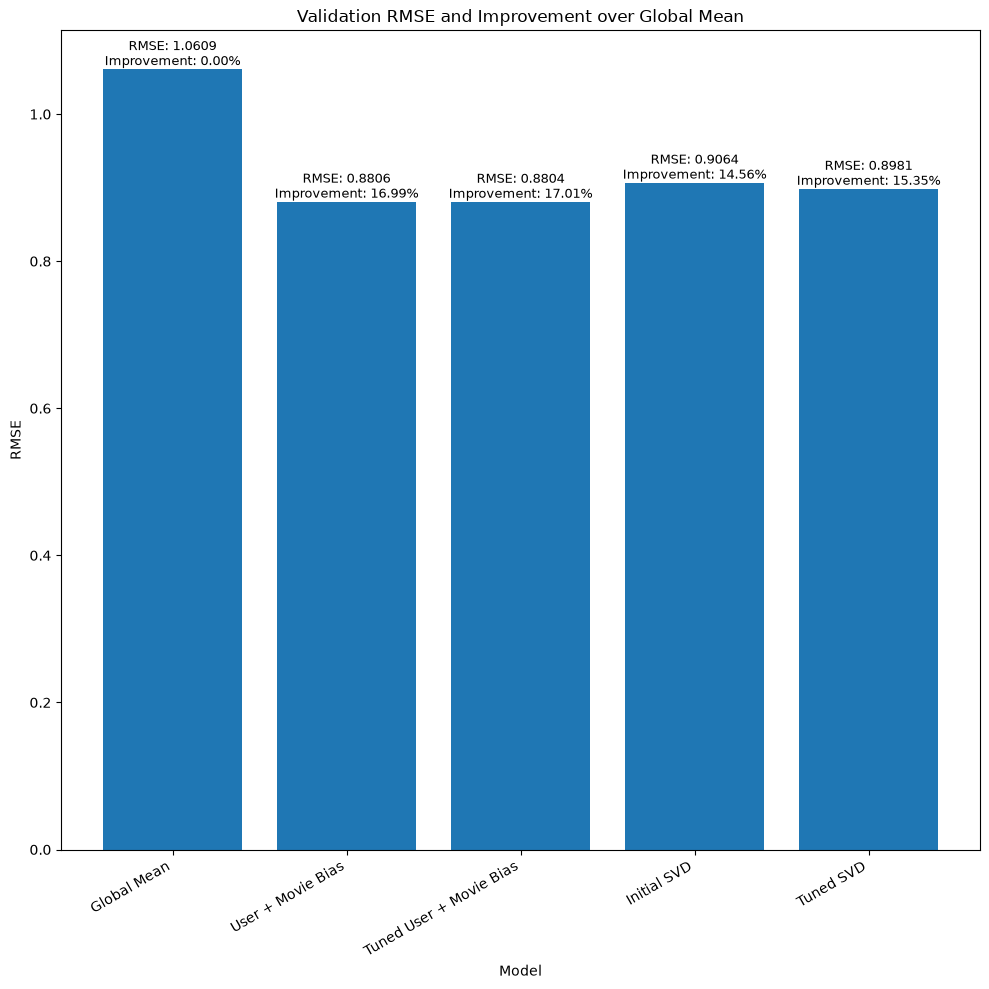

In [35]:
import matplotlib.pyplot as plt

baseline_rmse = 1.060875

model_results["Improvement (%)"] = (
    (baseline_rmse - model_results["RMSE"])
    / baseline_rmse
) * 100

plt.figure(figsize=(10, 10))

bars = plt.bar(
    model_results["Model"],
    model_results["RMSE"]
)

plt.ylabel("RMSE")
plt.xlabel("Model")
plt.title("Validation RMSE and Improvement over Global Mean")

plt.xticks(rotation=30, ha="right")

# Add RMSE and improvement percentage above each bar
for bar, rmse, improvement in zip(
    bars,
    model_results["RMSE"],
    model_results["Improvement (%)"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"RMSE: {rmse:.4f}\nImprovement: {improvement:.2f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "model_rmse_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 7.3 Model Ensemble

The individual model comparison showed that the **Tuned User + Movie Bias model** currently provides the best validation performance, while the **Tuned SVD model** captures user-movie relationships through latent factors.

Because the two models use different approaches, their prediction errors may differ. Combining their predictions may therefore produce a more accurate and robust model.

The ensemble prediction is calculated as:

$$
\hat{r}_{u,i}^{Ensemble}
=
w\hat{r}_{u,i}^{SVD}
+
(1-w)\hat{r}_{u,i}^{Bias}
$$

where:

* $\hat{r}_{u,i}^{SVD}$ = SVD prediction.
* $\hat{r}_{u,i}^{Bias}$ = User + Movie Bias prediction.
* $w$ = weight assigned to the SVD prediction.
* $(1-w)$ = weight assigned to the User + Movie Bias prediction.

Different weights will be tested, and the combination with the lowest validation RMSE will be selected.


### 7.3.1 Generating Predictions from the Best Models

The grid search identified **user regularization = 10** and **movie regularization = 20** as the best User + Movie Bias configuration, with a validation RMSE of **0.880417**.

We will now generate predictions using this exact configuration.

For comparison, the best SVD configuration identified during tuning uses **20 latent factors, 20 training epochs, and a regularization value of 0.05**.

The predictions from both models will then be used for ensemble testing.


In [36]:
# Best User + Movie Bias configuration

user_reg = 10
movie_reg = 20

best_user_bias = (
    (user_stats["sum"] - user_stats["count"] * global_mean_train)
    / (user_stats["count"] + user_reg)
)

best_movie_bias = (
    (movie_stats["sum"] - movie_stats["count"] * global_mean_train)
    / (movie_stats["count"] + movie_reg)
)

bias_predictions = (
    global_mean_train
    + validation_data["userId"].map(best_user_bias).fillna(0).values
    + validation_data["movieId"].map(best_movie_bias).fillna(0).values
)

print("Best Bias predictions generated successfully.")

Best Bias predictions generated successfully.


### 7.3.2 Training the Best SVD Model

The SVD tuning experiments identified the following configuration as the best:

* **20 latent factors**
* **20 training epochs**
* **Regularization = 0.05**
* **Validation RMSE = 0.898068**

We now train this selected SVD configuration so that its predictions can be combined with the predictions from the best User + Movie Bias model.

This ensures that the ensemble uses the best-performing configuration identified during the SVD tuning experiments.


In [37]:
best_svd_model = SVD(
    n_factors=20,
    n_epochs=20,
    reg_all=0.05,
    random_state=42
)

best_svd_model.fit(svd_trainset)

print("Best SVD model trained successfully.")

Best SVD model trained successfully.


### 7.3.3 Generating SVD Predictions

The best SVD model has now been trained using **20 latent factors, 20 training epochs, and a regularization value of 0.05**.

We now generate predictions for the validation dataset.

These predictions will be combined with the predictions from the best User + Movie Bias model in the ensemble experiment.


In [38]:
print("Generating SVD predictions...")

svd_predictions = []

for count, (_, row) in enumerate(validation_data.iterrows(), start=1):

    prediction = best_svd_model.predict(
        row["userId"],
        row["movieId"]
    ).est

    svd_predictions.append(prediction)

    if count % 50000 == 0:
        print(
            f"Processed: {count:,} / "
            f"{len(validation_data):,}"
        )

svd_predictions = np.array(svd_predictions)

print("SVD predictions generated successfully.")
print("Number of predictions:", len(svd_predictions))

Generating SVD predictions...
Processed: 50,000 / 2,000,008
Processed: 100,000 / 2,000,008
Processed: 150,000 / 2,000,008
Processed: 200,000 / 2,000,008
Processed: 250,000 / 2,000,008
Processed: 300,000 / 2,000,008
Processed: 350,000 / 2,000,008
Processed: 400,000 / 2,000,008
Processed: 450,000 / 2,000,008
Processed: 500,000 / 2,000,008
Processed: 550,000 / 2,000,008
Processed: 600,000 / 2,000,008
Processed: 650,000 / 2,000,008
Processed: 700,000 / 2,000,008
Processed: 750,000 / 2,000,008
Processed: 800,000 / 2,000,008
Processed: 850,000 / 2,000,008
Processed: 900,000 / 2,000,008
Processed: 950,000 / 2,000,008
Processed: 1,000,000 / 2,000,008
Processed: 1,050,000 / 2,000,008
Processed: 1,100,000 / 2,000,008
Processed: 1,150,000 / 2,000,008
Processed: 1,200,000 / 2,000,008
Processed: 1,250,000 / 2,000,008
Processed: 1,300,000 / 2,000,008
Processed: 1,350,000 / 2,000,008
Processed: 1,400,000 / 2,000,008
Processed: 1,450,000 / 2,000,008
Processed: 1,500,000 / 2,000,008
Processed: 1,550,00

### 7.3.4 Testing Ensemble Weights

The predictions from the two strongest individual models will now be combined using a weighted ensemble.

The ensemble prediction is defined as:
$$
\hat{r}_{ui} = w\hat{r}_{ui}^{SVD} + (1-w)\hat{r}_{ui}^{Bias}
$$
Different values of $w$ will be tested to determine how much influence the SVD model should have in the final prediction.

The weight values range from 0 to 1:

* $w=0$ uses only the User + Movie Bias model.
* $w=1$ uses only the SVD model.
* Values between 0 and 1 combine predictions from both models.

The weight producing the lowest validation RMSE will be selected as the best ensemble configuration.


In [39]:
ensemble_weights = [0.0, 0.25, 0.50, 0.75, 1.0]

ensemble_results = []

actual_ratings = validation_data["rating"].values

for weight in ensemble_weights:

    ensemble_predictions = (
        weight * svd_predictions
        + (1 - weight) * bias_predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual_ratings,
            ensemble_predictions
        )
    )

    ensemble_results.append(
        (weight, rmse)
    )

    print(
        f"SVD weight {weight:.2f}: "
        f"RMSE = {rmse:.6f}"
    )

SVD weight 0.00: RMSE = 0.880417
SVD weight 0.25: RMSE = 0.877906
SVD weight 0.50: RMSE = 0.880044
SVD weight 0.75: RMSE = 0.886800
SVD weight 1.00: RMSE = 0.898068


### Interpretation of Ensemble Results

The ensemble experiment shows that combining the User + Movie Bias model with SVD can improve validation performance.

| SVD Weight | Bias Weight |         RMSE |
| ---------: | ----------: | -----------: |
|       0.00 |        1.00 |     0.880417 |
|   **0.25** |    **0.75** | **0.877906** |
|       0.50 |        0.50 |     0.880044 |
|       0.75 |        0.25 |     0.886800 |
|       1.00 |        0.00 |     0.898068 |

The best result was obtained when **25% of the prediction came from SVD and 75% came from the User + Movie Bias model**.

This produced an RMSE of **0.877906**, improving upon the previous best individual model, the Tuned User + Movie Bias model (**RMSE = 0.880417**).

Although the improvement is relatively small, it demonstrates that the two models capture complementary information. The Bias model provides the stronger foundation, while a smaller contribution from SVD improves the overall prediction accuracy.

Therefore, the current best configuration is:

**75% User + Movie Bias + 25% SVD → RMSE = 0.877906**


### 7.3.5 Fine-Tuning the Ensemble Weight

The initial ensemble experiment identified an SVD weight of **0.25** as the best among the tested values.

To determine whether a slightly different weighting can produce a further improvement, we will perform a finer search around the **0.25** region.

The new weights will be tested without retraining either model because the predictions have already been generated.


In [40]:
fine_weights = [0.15, 0.20, 0.25, 0.30, 0.35]

fine_results = []

for weight in fine_weights:

    ensemble_predictions = (
        weight * svd_predictions
        + (1 - weight) * bias_predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual_ratings,
            ensemble_predictions
        )
    )

    fine_results.append(
        (weight, rmse)
    )

    print(
        f"SVD weight {weight:.2f}: "
        f"RMSE = {rmse:.6f}"
    )

SVD weight 0.15: RMSE = 0.878353
SVD weight 0.20: RMSE = 0.878036
SVD weight 0.25: RMSE = 0.877906
SVD weight 0.30: RMSE = 0.877961
SVD weight 0.35: RMSE = 0.878203


### Interpretation of Fine-Tuned Ensemble Weights

A finer search was performed around the initial best SVD weight of **0.25**.

| SVD Weight | Bias Weight |         RMSE |
| ---------: | ----------: | -----------: |
|       0.15 |        0.85 |     0.878353 |
|       0.20 |        0.80 |     0.878036 |
|   **0.25** |    **0.75** | **0.877906** |
|       0.30 |        0.70 |     0.877961 |
|       0.35 |        0.65 |     0.878203 |

The best result remained **0.25 SVD weight**, producing an RMSE of **0.877906**.

This confirms that the optimal weighting within the tested range is approximately:

**25% SVD + 75% User + Movie Bias**

The difference between the 0.25 and 0.30 configurations is extremely small, indicating that the ensemble is relatively stable around this region.

The final ensemble improves the RMSE from **0.880417** for the best individual Bias model to **0.877906**.

This represents an absolute RMSE improvement of **0.002511**.


## 7.4 Final Ensemble Configuration

The ensemble experiments identified the following configuration as the best-performing model on the validation dataset:

* **User + Movie Bias weight: 75%**
* **SVD weight: 25%**
* **Validation RMSE: 0.877906**

The final prediction is therefore calculated as:

$$
\hat{r}_{u,i}
=
0.75\hat{r}_{u,i}^{Bias}
+
0.25\hat{r}_{u,i}^{SVD}
$$

This configuration will be treated as the **final model selected from the validation experiments**.

The model selection is based entirely on validation RMSE, with lower RMSE indicating better predictive performance.


### 7.4.1 Calculate Final Validation Predictions

Using the selected ensemble weights, we now calculate the final predictions for the validation dataset.

The final prediction combines **75% of the User + Movie Bias prediction** with **25% of the SVD prediction**:

$$
\hat{r}_{ui}
=
0.75\hat{r}*{ui}^{Bias}
+
0.25\hat{r}*{ui}^{SVD}
$$

These predictions will be used to calculate the final validation RMSE and confirm the performance of the selected ensemble configuration.


In [41]:
best_svd_weight = 0.25
best_bias_weight = 0.75

final_validation_predictions = (
    best_bias_weight * bias_predictions
    + best_svd_weight * svd_predictions
)

final_validation_rmse = np.sqrt(
    mean_squared_error(
        actual_ratings,
        final_validation_predictions
    )
)

print(
    f"Final Ensemble Validation RMSE: "
    f"{final_validation_rmse:.6f}"
)

Final Ensemble Validation RMSE: 0.877906


### 7.4.2 Final Model Selection

Based on all validation experiments, the final selected model is a **weighted ensemble** of the User + Movie Bias model and the SVD model.

The selected configuration is:

| Component         | Configuration                     |  Weight |
| ----------------- | --------------------------------- | ------: |
| User + Movie Bias | User reg = 10, Movie reg = 20     | **75%** |
| SVD               | 20 factors, 20 epochs, reg = 0.05 | **25%** |

The final ensemble achieved a validation RMSE of **0.877906**.

This is an improvement over the previous best individual model:

* **Tuned User + Movie Bias:** 0.880417
* **Final Ensemble:** 0.877906
* **Absolute improvement:** 0.002511

The ensemble was selected because it produced the **lowest validation RMSE** among the tested configurations.

The validation stage is now complete. The selected ensemble will next be used to generate predictions for the **test dataset**.


# 8. Test Set Prediction & Submission

After completing model selection using the validation dataset, the final ensemble will be used to predict ratings for the **unseen test dataset**.

The selected ensemble combines:

* **75% User + Movie Bias**
* **25% SVD**

The validation experiments produced a best RMSE of **0.877906**.

The test dataset contains approximately **5 million user-movie pairs**. Because the computer has limited RAM, predictions will be generated in **manageable chunks** rather than loading and processing the entire test dataset at once.

This approach helps reduce memory pressure while allowing progress to be monitored during the prediction process.

The resulting predictions will then be formatted according to the required submission structure and saved for submission to the competition.


## 8.1 Loading the Test Dataset in Chunks

The test dataset contains approximately **5 million user-movie pairs**.

Because the available system memory is limited, the complete test dataset will not be loaded into memory at once. Instead, the file will be read in manageable chunks.

This approach allows predictions to be generated progressively while keeping memory usage under control.

### 8.1.1 Inspecting the Test Data

Before generating predictions, we inspect a small sample of the test dataset to confirm its structure.

Only a few rows are loaded at this stage to avoid unnecessary memory usage.


In [42]:
test_sample = pd.read_csv(
    test_path,
    nrows=5
)

print("Test sample loaded successfully.")
print(test_sample)

print("\nColumns:", test_sample.columns.tolist())
print("\nData types:")
print(test_sample.dtypes)

Test sample loaded successfully.
   userId  movieId
0       1     2011
1       1     4144
2       1     5767
3       1     6711
4       1     7318

Columns: ['userId', 'movieId']

Data types:
userId     int64
movieId    int64
dtype: object


## 8.2 Memory-Safe Test Prediction

The test dataset contains approximately **5 million user-movie pairs**. Because the available system memory is limited, the complete dataset will not be loaded into memory at once.

Instead, the test file will be processed in chunks of **100,000 rows**.

For each chunk:

1. User + Movie Bias predictions will be generated.
2. SVD predictions will be generated.
3. The two predictions will be combined using the selected ensemble weights.
4. The predictions will be written to the submission file.
5. The chunk will then be released from memory.

The final prediction is:

$$
\hat{r}_{ui}
=
0.75\hat{r}*{ui}^{Bias}
+
0.25\hat{r}*{ui}^{SVD}
$$

This approach minimizes memory usage while allowing the complete test dataset to be processed without requiring the entire test set to remain in memory.


In [43]:
test_chunk = pd.read_csv(
    test_path,
    nrows=100_000
)

print("Test chunk loaded successfully.")
print("Chunk shape:", test_chunk.shape)
print("\nCurrent available RAM:")

print(f"Total RAM: {ram.total / (1024**3):.2f} GB")
print(f"Available RAM: {ram.available / (1024**3):.2f} GB")
print(f"Used RAM: {ram.used / (1024**3):.2f} GB")
print(f"Percent Used: {ram.percent:.1f}%")

Test chunk loaded successfully.
Chunk shape: (100000, 2)

Current available RAM:
Total RAM: 7.88 GB
Available RAM: 1.41 GB
Used RAM: 6.47 GB
Percent Used: 82.1%


### 8.2.1 Testing Prediction on a Single Chunk

Before processing the complete test dataset, the prediction pipeline is tested on a single **100,000-row chunk**.

This allows us to verify that both the **User + Movie Bias model** and the **SVD model** can generate predictions successfully for unseen user-movie pairs.

The resulting predictions will not yet be written to the final submission file.

This test helps identify potential errors in the prediction pipeline before processing the full test dataset.


In [44]:
# Best Bias parameters
user_reg = 10
movie_reg = 20

# Calculate user and movie biases
test_user_bias = (
    (user_stats["sum"] - user_stats["count"] * global_mean_train)
    / (user_stats["count"] + user_reg)
)

test_movie_bias = (
    (movie_stats["sum"] - movie_stats["count"] * global_mean_train)
    / (movie_stats["count"] + movie_reg)
)

# Generate Bias predictions
chunk_bias_predictions = (
    global_mean_train
    + test_chunk["userId"].map(test_user_bias).fillna(0).values
    + test_chunk["movieId"].map(test_movie_bias).fillna(0).values
)

print("Bias predictions generated.")
print("Number of Bias predictions:", len(chunk_bias_predictions))

Bias predictions generated.
Number of Bias predictions: 100000


### 8.2.2 Generating SVD Predictions for the Test Chunk

The trained SVD model is now used to generate predictions for the same test chunk.

The model predicts a rating for each user-movie pair using the latent factors learned during training.

Testing this on one chunk first allows us to confirm that the SVD prediction process works correctly before processing the complete test dataset.


In [45]:
print("Generating SVD predictions...")

chunk_svd_predictions = []

for count, (_, row) in enumerate(test_chunk.iterrows(), start=1):

    prediction = best_svd_model.predict(
        row["userId"],
        row["movieId"]
    ).est

    chunk_svd_predictions.append(prediction)

chunk_svd_predictions = np.array(chunk_svd_predictions)

print("SVD predictions generated.")
print("Number of SVD predictions:", len(chunk_svd_predictions))


Generating SVD predictions...
SVD predictions generated.
Number of SVD predictions: 100000


### 8.2.3 Generating Final Ensemble Predictions

The User + Movie Bias and SVD predictions are combined using the final weights selected during validation:

* **75% User + Movie Bias**
* **25% SVD**

The resulting predictions represent the **final model output** for the test chunk.

Before processing the complete test dataset, the prediction range and structure will be checked to ensure that the pipeline is producing sensible results.


In [46]:
# Final ensemble weights
bias_weight = 0.75
svd_weight = 0.25

chunk_final_predictions = (
    bias_weight * chunk_bias_predictions
    + svd_weight * chunk_svd_predictions
)

print("Final ensemble predictions generated.")
print("Number of predictions:", len(chunk_final_predictions))

print("\nPrediction statistics:")
print(f"Minimum: {chunk_final_predictions.min():.4f}")
print(f"Maximum: {chunk_final_predictions.max():.4f}")
print(f"Mean:    {chunk_final_predictions.mean():.4f}")

print("\nFirst 10 predictions:")
print(chunk_final_predictions[:10])

Final ensemble predictions generated.
Number of predictions: 100000

Prediction statistics:
Minimum: -0.1622
Maximum: 5.2948
Mean:    3.5370

First 10 predictions:
[3.77847755 4.28057424 3.73802992 4.02655189 3.37416843 3.88341137
 3.93980163 3.90426085 4.07178327 3.92304166]


### 8.2.4 Clipping Predictions to the Valid Rating Range

MovieLens ratings range from **0.5 to 5.0**.

Although the ensemble produces generally reasonable predictions, a small number of predictions may fall outside this valid range.

To ensure that the final submission contains valid rating values, predictions will be clipped to the interval **[0.5, 5.0]**.

This does not change predictions that already fall within the valid rating range.


In [47]:
# Clip predictions to the valid MovieLens rating range
chunk_final_predictions = np.clip(
    chunk_final_predictions,
    0.5,
    5.0
)

print("Predictions clipped successfully.")

print("\nClipped prediction statistics:")
print(f"Minimum: {chunk_final_predictions.min():.4f}")
print(f"Maximum: {chunk_final_predictions.max():.4f}")
print(f"Mean:    {chunk_final_predictions.mean():.4f}")

print("\nNumber below 0.5:",
      np.sum(chunk_final_predictions < 0.5))

print("Number above 5.0:",
      np.sum(chunk_final_predictions > 5.0))

Predictions clipped successfully.

Clipped prediction statistics:
Minimum: 0.5000
Maximum: 5.0000
Mean:    3.5369

Number below 0.5: 0
Number above 5.0: 0


## 8.3 Full Test Prediction

The prediction pipeline has been successfully tested on a **100,000-row sample**.

The complete test dataset will now be processed in chunks of **100,000 rows** to control memory usage.

For each chunk:

1. User and movie bias predictions are generated using the selected regularization values.
2. SVD predictions are generated.
3. The predictions are combined using the final weights:

   * **75% User + Movie Bias**
   * **25% SVD**
4. Predictions are clipped to the valid rating range of **0.5–5.0**.
5. The predictions are written directly to the submission file.

Only one chunk is kept in memory at a time. This minimizes memory usage while allowing the complete test dataset to be processed.


### 8.3.1 Preparing the Final Submission File

A new submission file will be created to store the predictions generated from the final ensemble model.

The original `sample_submission.csv` will be preserved as a reference. The new file will contain the predictions generated from the test dataset.

Predictions will be written progressively as each test chunk is processed, avoiding the need to keep the complete set of approximately 5 million predictions in memory.

In [48]:
submission_output_path = os.path.join(
    data_path,
    "final_submission.csv"
)

print("Output file:")
print(submission_output_path)

Output file:
C:\Users\TITILOPE\OneDrive\Downloads\ALX DATA SCIENCE LEARNINGS\3_MACHINE LEARNING\3_UNSUPERVISED LEARNING MODULES\movie-recommendation-hackathon-2026\final_submission.csv


### 8.3.2 Full Test Prediction and Submission

The complete test dataset will now be processed in chunks of 100,000 rows.

For each chunk, the final ensemble will generate predictions using:

- **75% User + Movie Bias**
- **25% SVD**

The predictions will then be clipped to the valid rating range of **0.5 to 5.0** and written directly to the final submission file.

Processing the data incrementally prevents the complete test dataset and prediction array from occupying memory simultaneously.

Progress will be displayed after each processed chunk.

In [49]:
import gc

test_chunksize = 100_000

# Remove the previous test chunk objects from memory
del test_chunk
del chunk_bias_predictions
del chunk_svd_predictions
del chunk_final_predictions

gc.collect()

print("Memory cleaned.")

Memory cleaned.


In [50]:
# Recalculate the final Bias components
user_reg = 10
movie_reg = 20

final_user_bias = (
    (user_stats["sum"] - user_stats["count"] * global_mean_train)
    / (user_stats["count"] + user_reg)
)

final_movie_bias = (
    (movie_stats["sum"] - movie_stats["count"] * global_mean_train)
    / (movie_stats["count"] + movie_reg)
)

# Open test data in chunks
test_reader = pd.read_csv(
    test_path,
    chunksize=test_chunksize
)

total_processed = 0
first_chunk = True

print("Starting full test prediction...\n")

for test_chunk in test_reader:

    # --------------------------------------------------
    # 1. User + Movie Bias predictions
    # --------------------------------------------------
    
    bias_pred = (
        global_mean_train
        + test_chunk["userId"].map(final_user_bias).fillna(0).values
        + test_chunk["movieId"].map(final_movie_bias).fillna(0).values
    )

    # --------------------------------------------------
    # 2. SVD predictions
    # --------------------------------------------------
    
    svd_pred = []

    for _, row in test_chunk.iterrows():

        prediction = best_svd_model.predict(
            row["userId"],
            row["movieId"]
        ).est

        svd_pred.append(prediction)

    svd_pred = np.array(svd_pred)

    # --------------------------------------------------
    # 3. Final ensemble
    # --------------------------------------------------
    
    final_pred = (
        0.75 * bias_pred
        + 0.25 * svd_pred
    )

    # --------------------------------------------------
    # 4. Clip to valid rating range
    # --------------------------------------------------
    
    final_pred = np.clip(
        final_pred,
        0.5,
        5.0
    )

    # --------------------------------------------------
    # 5. Create submission chunk
    # --------------------------------------------------
    
    submission_chunk = test_chunk.copy()
    submission_chunk["rating"] = final_pred

    # --------------------------------------------------
    # 6. Write to submission file
    # --------------------------------------------------
    
    submission_chunk.to_csv(
        submission_output_path,
        mode="w" if first_chunk else "a",
        header=first_chunk,
        index=False
    )

    first_chunk = False

    total_processed += len(test_chunk)

    print(
        f"Processed: {total_processed:,}"
    )

    # Release memory
    del test_chunk
    del bias_pred
    del svd_pred
    del final_pred
    del submission_chunk

    gc.collect()

print("\nFull test prediction completed.")
print(f"Total predictions: {total_processed:,}")
print("Submission file created successfully.")

Starting full test prediction...

Processed: 100,000
Processed: 200,000
Processed: 300,000
Processed: 400,000
Processed: 500,000
Processed: 600,000
Processed: 700,000
Processed: 800,000
Processed: 900,000
Processed: 1,000,000
Processed: 1,100,000
Processed: 1,200,000
Processed: 1,300,000
Processed: 1,400,000
Processed: 1,500,000
Processed: 1,600,000
Processed: 1,700,000
Processed: 1,800,000
Processed: 1,900,000
Processed: 2,000,000
Processed: 2,100,000
Processed: 2,200,000
Processed: 2,300,000
Processed: 2,400,000
Processed: 2,500,000
Processed: 2,600,000
Processed: 2,700,000
Processed: 2,800,000
Processed: 2,900,000
Processed: 3,000,000
Processed: 3,100,000
Processed: 3,200,000
Processed: 3,300,000
Processed: 3,400,000
Processed: 3,500,000
Processed: 3,600,000
Processed: 3,700,000
Processed: 3,800,000
Processed: 3,900,000
Processed: 4,000,000
Processed: 4,100,000
Processed: 4,200,000
Processed: 4,300,000
Processed: 4,400,000
Processed: 4,500,000
Processed: 4,600,000
Processed: 4,700,0

## 8.4 Submission Validation

Before submitting the predictions to Kaggle, the final submission file will be validated to ensure that:

- All expected rows are present.
- The required columns are present.
- There are no missing predictions.
- All predicted ratings fall within the valid range of 0.5 to 5.0.
- The number of predictions matches the test dataset.

This validation helps prevent formatting or data-quality errors from affecting the Kaggle submission.

### 8.4.1 Checking the Submission File

The final submission file is now loaded and checked for structural and data-quality issues.

The validation will confirm the number of rows, column names, missing predictions, rating range, and whether the submission contains the expected **5,000,019 predictions**.


In [51]:
submission_check = pd.read_csv(submission_output_path)

print("Submission shape:", submission_check.shape)

print("\nColumns:")
print(submission_check.columns.tolist())

print("\nMissing values:")
print(submission_check.isnull().sum())

print("\nRating statistics:")
print(submission_check["rating"].describe())

print("\nMinimum rating:", submission_check["rating"].min())
print("Maximum rating:", submission_check["rating"].max())

print("\nExpected rows:", 5_000_019)
print("Actual rows:", len(submission_check))
print("Row count correct:", len(submission_check) == 5_000_019)

Submission shape: (5000019, 3)

Columns:
['userId', 'movieId', 'rating']

Missing values:
userId     0
movieId    0
rating     0
dtype: int64

Rating statistics:
count    5.000019e+06
mean     3.528486e+00
std      6.138697e-01
min      5.000000e-01
25%      3.151010e+00
50%      3.588473e+00
75%      3.972077e+00
max      5.000000e+00
Name: rating, dtype: float64

Minimum rating: 0.5
Maximum rating: 5.0

Expected rows: 5000019
Actual rows: 5000019
Row count correct: True


### 8.4.2 Final Submission Summary

The final submission file has passed all structural and data-quality checks.

The submission contains **5,000,019 predictions**, matching the number of records in the test dataset. No missing values were detected, and all predicted ratings fall within the valid MovieLens rating range of **0.5 to 5.0**.

The submitted predictions were generated using the final ensemble:

* **75% User + Movie Bias**
* **25% SVD**

The ensemble achieved a validation RMSE of **0.877906**.

The submission file is now ready for **Kaggle submission and evaluation**.


### 8.4.3 Inspecting the Kaggle Submission Template

The first submission was rejected by Kaggle despite passing the local validation checks.

To identify the cause, the official `sample_submission.csv` provided with the competition will be inspected.

The sample submission serves as the **authoritative template** for the required column names, row structure, and submission format.

The template will be compared with the generated submission file to identify any differences that may have caused the rejection.


In [52]:
sample_submission_check = pd.read_csv(
    submission_path,
    nrows=5
)

print("Sample submission columns:")
print(sample_submission_check.columns.tolist())

print("\nSample submission shape (first 5 rows):")
print(sample_submission_check)

print("\nData types:")
print(sample_submission_check.dtypes)

Sample submission columns:
['Id', 'rating']

Sample submission shape (first 5 rows):
       Id  rating
0  1_2011     1.0
1  1_4144     1.0
2  1_5767     1.0
3  1_6711     1.0
4  1_7318     1.0

Data types:
Id            str
rating    float64
dtype: object


### 8.4.4 Correcting the Submission Format

The initial submission was rejected because the generated file did not follow the competition's required submission format.

The official template requires two columns:

* `Id`
* `rating`

The `Id` combines the `userId` and `movieId` values using an underscore in the following format:

`userId_movieId`

The existing predictions will therefore be reformatted to match the **official submission template**, without regenerating the model predictions.

This ensures that the corrected submission preserves the predictions produced by the final ensemble while matching Kaggle's required file structure.


In [53]:
# Load our existing predictions
final_predictions = pd.read_csv(
    submission_output_path
)

# Create Kaggle's required Id format
final_predictions["Id"] = (
    final_predictions["userId"].astype(str)
    + "_"
    + final_predictions["movieId"].astype(str)
)

# Keep only the required Kaggle columns
kaggle_submission = final_predictions[
    ["Id", "rating"]
]

# Save corrected submission
corrected_submission_path = os.path.join(
    data_path,
    "final_submission_corrected.csv"
)

kaggle_submission.to_csv(
    corrected_submission_path,
    index=False
)

print("Corrected submission created successfully.")
print("Path:", corrected_submission_path)
print("Shape:", kaggle_submission.shape)

print("\nFirst 5 rows:")
print(kaggle_submission.head())

Corrected submission created successfully.
Path: C:\Users\TITILOPE\OneDrive\Downloads\ALX DATA SCIENCE LEARNINGS\3_MACHINE LEARNING\3_UNSUPERVISED LEARNING MODULES\movie-recommendation-hackathon-2026\final_submission_corrected.csv
Shape: (5000019, 2)

First 5 rows:
       Id    rating
0  1_2011  3.778478
1  1_4144  4.280574
2  1_5767  3.738030
3  1_6711  4.026552
4  1_7318  3.374168


### 8.4.5 Final Submission Format Validation

The corrected submission is compared with the official `sample_submission.csv` format before uploading to Kaggle.

This final check confirms that:

* The column names and order match the official template.
* The submission contains the expected **5,000,019 rows**.
* The `Id` values follow the required identifier format.
* The predictions contain no missing values.
* All predicted ratings fall within the valid range of **0.5 to 5.0**.

Once these checks pass, the corrected submission file is ready to be uploaded to Kaggle.


In [54]:
print("Column names match:",
      list(kaggle_submission.columns)
      == list(sample_submission_check.columns))

print("Row count:",
      len(kaggle_submission))

print("Expected row count:",
      5_000_019)

print("Missing values:")
print(kaggle_submission.isnull().sum())

print("\nRating range:")
print("Minimum:", kaggle_submission["rating"].min())
print("Maximum:", kaggle_submission["rating"].max())

print("\nFirst 5 IDs:")
print(kaggle_submission["Id"].head().tolist())

print("\nLast 5 IDs:")
print(kaggle_submission["Id"].tail().tolist())

Column names match: True
Row count: 5000019
Expected row count: 5000019
Missing values:
Id        0
rating    0
dtype: int64

Rating range:
Minimum: 0.5
Maximum: 5.0

First 5 IDs:
['1_2011', '1_4144', '1_5767', '1_6711', '1_7318']

Last 5 IDs:
['162541_4079', '162541_4467', '162541_4980', '162541_5689', '162541_7153']


## 8.5 Kaggle Submission Result

The final ensemble model was submitted to the Kaggle competition using the complete test dataset of **5,000,019 records**.

The submitted predictions were generated using the final ensemble:

* **75% User + Movie Bias**
* **25% SVD**

The final ensemble achieved a validation RMSE of **0.877906**.

The submission did not surpass the current leaderboard reference score of **0.77**. However, the project successfully demonstrated a complete recommendation-system workflow, including:

* Exploratory data analysis
* Baseline modelling
* User and movie bias modelling
* Matrix factorization with SVD
* Hyperparameter tuning
* Ensemble modelling
* Memory-efficient test prediction
* Submission validation and formatting
* Kaggle competition submission

Although the final model did not reach the leaderboard target, the experiments demonstrated that combining complementary recommendation approaches can improve performance over individual models. The project also established a solid foundation for further model improvements.


## 9. Final Model & Results

After evaluating the different recommendation approaches and tuning their parameters, the final models were compared using **Root Mean Squared Error (RMSE)** on the validation dataset.

The experiments covered:

* Global Mean baseline
* User + Movie Bias
* SVD with different numbers of latent factors
* SVD with different training epochs
* SVD with different regularization values
* A weighted ensemble combining SVD with User + Movie Bias

The purpose of this section is to summarize the final results and identify the model selected for generating the Kaggle test predictions.


In [61]:
# Let's create a clean results table from the important results we've recorded.

final_results = pd.DataFrame({
    "Model": [
        "Global Mean",
        "User + Movie Bias",
        "Tuned User + Movie Bias",
        "SVD (50 factors, 20 epochs,)",
        "SVD (20 factors, 20 epochs, reg=0.05)",
        "SVD + User/Movie Bias Ensemble"
    ],
    "RMSE": [
        1.060875,
        0.880608,
        0.880417,
        0.906448,
        0.898068,
        0.877906
    ]
})

final_results = final_results.sort_values("RMSE")

final_results

,Model,RMSE
5,SVD + User/Movie Bias Ensemble,0.877906
2,Tuned User + Movie Bias,0.880417
1,User + Movie Bias,0.880608
4,"SVD (20 factors, 20 epochs, reg=0.05)",0.898068
3,"SVD (50 factors, 20 epochs,)",0.906448
0,Global Mean,1.060875


### 9.1 Interpretation of Final Model Results

The results show that **different modelling approaches produced different levels of performance**, demonstrating that greater model complexity does not necessarily lead to lower RMSE.

The **Global Mean baseline** achieved an RMSE of **1.060875**, providing a reference point for evaluating the other models.

The initial **SVD model** achieved **0.906448**. Hyperparameter tuning improved the SVD model to **0.898068**, showing that parameter selection had a measurable effect on performance.

The **User + Movie Bias model** achieved a lower RMSE of **0.880417**, indicating that accounting for systematic differences in user and movie rating behaviour was particularly effective for this dataset.

Finally, the **weighted ensemble** combining the tuned Bias model and tuned SVD model achieved the lowest validation RMSE of **0.877906**.

Although the improvement over the Bias model was relatively small, the ensemble produced the **strongest validation performance among the tested approaches**.

Based on these results, the **SVD + User/Movie Bias ensemble** was selected to generate the final Kaggle test predictions.

The final competition result was approximately **0.87 RMSE on the Kaggle public leaderboard**, with a **rank of 294**.


### 9.2 Final Model Comparison

The following visualization compares the RMSE performance of the evaluated models.

Since **lower RMSE indicates better predictive performance**, the model with the lowest RMSE represents the strongest validation performance.

The comparison highlights the progression from the **Global Mean baseline** to the **User + Movie Bias model**, SVD, the tuned SVD model, and finally the weighted ensemble.

The **SVD + User/Movie Bias ensemble achieved the lowest validation RMSE of 0.877906**.


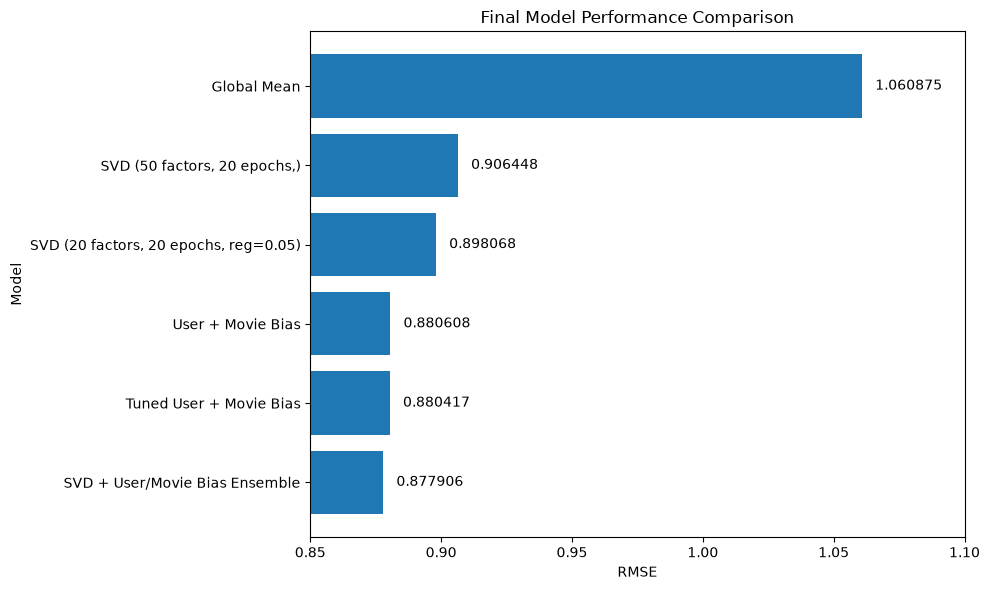

Visualization saved successfully.
Path: C:\Users\TITILOPE\OneDrive\Downloads\ALX DATA SCIENCE LEARNINGS\3_MACHINE LEARNING\3_UNSUPERVISED LEARNING MODULES\movie-recommendation-hackathon-2026\final_model_comparison.png


In [62]:
import matplotlib.pyplot as plt
import os

# ------------------------------------------------------------
# Final Model Comparison Visualization
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

bars = plt.barh(
    final_results["Model"],
    final_results["RMSE"]
)

plt.xlabel("RMSE")
plt.ylabel("Model")
plt.title("Final Model Performance Comparison")

# Add RMSE values to each bar
for bar, value in zip(bars, final_results["RMSE"]):
    plt.text(
        value + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.6f}",
        va="center"
    )

# Focus on the range where most models are clustered
plt.xlim(0.85, 1.10)

plt.tight_layout()

# ------------------------------------------------------------
# Save visualization
# ------------------------------------------------------------

comparison_plot_path = os.path.join(
    data_path,
    "final_model_comparison.png"
)

plt.savefig(
    comparison_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Visualization saved successfully.")
print("Path:", comparison_plot_path)

# 10. Project Conclusions

This project developed and evaluated a **Movie Recommendation System** using the MovieLens dataset containing more than **10 million ratings**.

The modelling process progressed from a **Global Mean baseline** to **User + Movie Bias**, **SVD**, hyperparameter tuning, and weighted ensemble modelling.

The **SVD + User/Movie Bias ensemble** achieved the best validation performance with an RMSE of **0.877906**. The selected ensemble was then used to generate predictions for all **5,000,019 test records** using memory-efficient chunk processing.

The final submission achieved approximately **0.87 RMSE on the Kaggle public leaderboard** and a **rank of 294**.

Although the result did not surpass the **0.77 leaderboard benchmark**, the project demonstrated an end-to-end recommender-system workflow covering data exploration, baseline modelling, collaborative filtering, hyperparameter tuning, ensemble modelling, large-scale prediction, validation, and Kaggle submission.

The project also demonstrated the importance of **memory-aware processing** when working with large datasets under limited computing resources.


### 10.1 Key Lessons Learned

**1. Strong baselines are important**

The Global Mean provided a simple reference point for measuring whether more advanced models improved performance.

**2. More complex models do not always perform better**

SVD was more sophisticated, but the User + Movie Bias model achieved a lower RMSE. This reinforced the importance of evaluating models empirically rather than assuming greater complexity will produce better results.

**3. Hyperparameter tuning matters**

Testing different latent factors, training epochs, and regularization values improved SVD performance from **0.906448 to 0.898068**.

**4. Complementary models can work well together**

The weighted ensemble achieved the best validation RMSE of **0.877906**, showing that combining different modelling approaches can provide a small but measurable improvement.

**5. Resource management is part of machine learning**

The large dataset and limited RAM required memory-efficient processing, particularly when generating predictions for the full test dataset.

**6. Validation results should be compared with unseen data**

The validation RMSE of **0.877906** was close to the approximately **0.87 RMSE** obtained on the Kaggle public leaderboard. The similarity between the validation and public leaderboard RMSE values suggests that the validation result was reasonably representative of the competition evaluation.

**7. There is room for further improvement**

The Rank 294 result provides a measurable starting point for a second phase focused on improving the recommender system and challenging the stronger leaderboard results.


### 10.2 Limitations & Future Improvements

Several limitations remain and provide opportunities for further development.

**1. Limited computational resources**

The size of the dataset and available RAM restricted some experiments and required memory-efficient processing techniques.

**2. Limited SVD search space**

The SVD experiments explored a relatively small range of latent factors, epochs, and regularization values. A broader search could potentially identify stronger configurations.

**3. Limited model diversity**

The final ensemble combined User + Movie Bias and SVD. Future experiments could investigate approaches such as:

* SVD++
* Item-based collaborative filtering
* User-based collaborative filtering
* Neural collaborative filtering
* Hybrid recommendation models

**4. Additional movie information was not fully exploited**

The dataset contains genres, tags, genome scores, and IMDb-related information. Incorporating these features could support a hybrid recommendation approach.

**5. Further ensemble optimization**

A broader search of ensemble weights or a stacking approach could potentially improve upon the current result.

### Future Direction

The next phase of the project will focus on improving the current recommender system through additional recommendation algorithms, richer movie features, broader hyperparameter experimentation, and improved ensemble strategies.

The goal is to improve upon the current approximately 0.87 Kaggle RMSE and challenge the 0.77 leaderboard benchmark.

# 11. Final Project Summary

This project developed a **Movie Recommendation System** using the MovieLens dataset and evaluated several collaborative filtering approaches.

The project progressed from a **Global Mean baseline** to **User + Movie Bias**, SVD, hyperparameter tuning, and ensemble modelling.

The best individual model was the **User + Movie Bias model**, achieving an RMSE of **0.880417**.

Combining the tuned Bias model with the tuned SVD model produced the best validation result:

### **Validation RMSE: 0.877906**

The final ensemble used:

* **75% User + Movie Bias**
* **25% SVD**

The ensemble generated predictions for all **5,000,019 test records**, using chunk-based processing to manage memory usage.

### Final Outcome

| Metric               |        Result |
| -------------------- | ------------: |
| Best Validation RMSE |  **0.877906** |
| Kaggle Public RMSE   |     **~0.87** |
| Kaggle Rank          |       **294** |
| Test Predictions     | **5,000,019** |

The project provides a foundation for a second phase focused on improving the recommender system through **additional models, richer features, broader experimentation, and improved ensemble strategies**.


## AI Assistance

AI tools were used as a learning and development aid for code guidance, debugging, documentation, and interpretation. The project workflow, experiments, results, and final implementation were reviewed and verified by the author.
